In [209]:
from sklearn import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
Development_df = pd.read_excel('/Users/Keyan/Downloads/Finalized_Cleaned_Determinants_of_GDP_and_HDI.xlsx')
pd.set_option('display.max_columns', None)
Development_df.head()  # This displays the first 5 rows of the dataset

,Country,Year,Avg_Yrs_Schooling,Dependency_Ratio,Energy_Cons_Per_Cap,EPop_Pct,Fixed_Capital_Format_GDPpct,GDP_Per_Capita_PPP,Global_Commodity_Price_Index,HDI,Pct_in_Agriculture,Pct_urban_areas,Pop_Growth_Pct,Resource_Rents_Pct_GDP,Rule_of_Law_index,Trade_Pct_GDP
0,Albania,2000,8.750522,58.588726,6216.7456,49.528,34.040139,3977.793158,25.86253,0.682,50.467464,41.613583,-0.637357,1.205807,0.474,61.609260
1,Albania,2001,8.820000,57.827007,6383.7065,48.965,38.228045,4450.511351,-7.01529,0.691,49.435272,42.354515,-0.938470,0.774294,0.518,64.247444
2,Albania,2002,8.885714,56.728830,7213.5920,48.945,38.575336,4840.358546,-0.77551,0.697,48.371387,43.152042,-0.299877,0.765809,0.515,65.991460
3,Albania,2003,8.951428,55.605934,7441.4790,48.611,36.722128,5169.163145,17.50807,0.705,48.276344,44.029510,-0.374149,0.765832,0.511,64.823210
4,Albania,2004,9.017142,54.512900,8072.5440,48.121,36.331947,5594.816886,20.59162,0.710,47.916664,44.978493,-0.417931,0.868822,0.529,65.037940


In [334]:
Development_df.columns = Development_df.columns.str.strip()
#This removes the leading spaces before the variable names

for col in Development_df.columns:
    print(col)
#Displays the names for all of the columns, one per line

Development_df_filtered = Development_df[(Development_df["Pop_Growth_Pct"] <= 4) & (Development_df["Pop_Growth_Pct"] >= -2)]
Development_df_filtered = Development_df_filtered[(Development_df_filtered["Trade_Pct_GDP"] <= 200)]
Development_df_filtered = Development_df_filtered[(Development_df_filtered["Fixed_Capital_Format_GDPpct"] <= 50)]

Development_df_filtered = Development_df_filtered.copy()
#Since this code had a few outliers that ruined a relationship between an IV and a DV, I removed those points
#(Mostly Qatar, Bahrain, and Kuwait up to about 2015)



Development_df_filtered = Development_df_filtered.reset_index()

Development_df_filtered.columns

Country
Year
Avg_Yrs_Schooling
Dependency_Ratio
Energy_Cons_Per_Cap
EPop_Pct
Fixed_Capital_Format_GDPpct
GDP_Per_Capita_PPP
Global_Commodity_Price_Index
HDI
Pct_in_Agriculture
Pct_urban_areas
Pop_Growth_Pct
Resource_Rents_Pct_GDP
Rule_of_Law_index
Trade_Pct_GDP


Index(['index', 'Country', 'Year', 'Avg_Yrs_Schooling', 'Dependency_Ratio',
       'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
       'GDP_Per_Capita_PPP', 'Global_Commodity_Price_Index', 'HDI',
       'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct',
       'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP'],
      dtype='object')

In [211]:
print("Skew of All Variables:")
print("-"*40)
print(Development_df_filtered.select_dtypes(include=np.number).skew())

print("\n\nAll Variables With a Skew of At Least 0.8 (Absolute Value)")
print("-"*58)
skew_values = Development_df_filtered.select_dtypes(include=np.number).skew()
print(skew_values[abs(skew_values) >= 0.8])

#Gives the skew for each of the variables, independent, and dependent variables

Skew of All Variables:
----------------------------------------
Year                           -0.051224
Avg_Yrs_Schooling              -0.262737
Dependency_Ratio                0.755244
Energy_Cons_Per_Cap             2.640127
EPop_Pct                        0.078401
Fixed_Capital_Format_GDPpct     0.592416
GDP_Per_Capita_PPP              1.860931
Global_Commodity_Price_Index   -0.005860
HDI                            -0.366925
Pct_in_Agriculture              0.659308
Pct_urban_areas                -0.184234
Pop_Growth_Pct                 -0.049315
Resource_Rents_Pct_GDP          2.576462
Rule_of_Law_index              -0.047900
Trade_Pct_GDP                   0.822279
dtype: float64


All Variables With a Skew of At Least 0.8 (Absolute Value)
----------------------------------------------------------
Energy_Cons_Per_Cap       2.640127
GDP_Per_Capita_PPP        1.860931
Resource_Rents_Pct_GDP    2.576462
Trade_Pct_GDP             0.822279
dtype: float64


In [212]:
#Comparing transformations to see which is best


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
def compare_model(X, y, name):
    model = LinearRegression()

    rmse = -cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    r2 = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    ).mean()

    print(f"{name}")
    print(f"RMSE: {rmse:.5f}")
    print(f"R²: {r2:.5f}")
    print()




#1
X = Development_df_filtered[["Pop_Growth_Pct"]]
Development_df_filtered["log_GDP_PPP"] = np.log(Development_df_filtered["GDP_Per_Capita_PPP"])
y = Development_df_filtered["log_GDP_PPP"]
#y = Development_df_filtered["HDI"]
compare_model(X, y, "Exponential/Log-Linear")

#2
#Development_df_filtered["log_PopGrowth"] = np.log1p(Development_df_filtered["Pop_Growth_Pct"])
#X=Development_df_filtered[["log_PopGrowth"]]
#compare_model(X, y, "Log")

#3
Development_df_filtered["PopGrowth_squared"] = (Development_df_filtered["Pop_Growth_Pct"]**2)
X=Development_df_filtered[["Pop_Growth_Pct", "PopGrowth_squared"]]
compare_model(X, y, "Squared Quadratic")

#4
Development_df_filtered["PopGrowth_cubed"] = (Development_df_filtered["Pop_Growth_Pct"]**3)
X = Development_df_filtered[["Pop_Growth_Pct", "PopGrowth_squared", "PopGrowth_cubed"]]
compare_model(X, y, "Cubed Quadratic/Cubic")

#5
#Development_df_filtered["sqrt_PopGrowth"] = np.sqrt(Development_df_filtered["Pop_Growth_Pct"])
#X = Development_df_filtered[["sqrt_PopGrowth"]]
#compare_model(X, y, "Square Root")

#6
#Development_df_filtered["recip_PopGrowth"] = (1 / Development_df_filtered["Pop_Growth_Pct"])
#X = Development_df_filtered[["recip_PopGrowth"]]
#compare_model(X, y, "Reciprocal")


#Development_df_filtered["PopGrowth_Dependency"] = (Development_df_filtered["Pop_Growth_Pct"] * Development_df_filtered["Dependency_Ratio"])
#X = Development_df_filtered[["PopGrowth_Dependency"]]
#compare_model(X, y, "Interaction")



#I put the final one I did here, but I did the same test with every other variable to see which specification is best


#For X1 (For GDP Growth %)
#This was originally going to be my first model, but the results were uninteresting and didn't fit well for a regression or any ML components
#because GDP Growth is often a result of catch up growth, and high growth doesn't mean good fundamentals. Additionally, in the case of all
#of these, there were some extra variables that I looked at, before I came to my final model which contains fewer variables (only about 12-13)
#I originally made a model to see what would affect GDP growth, but as I suspected, it's noisier than I'd like
#This is because (paradoxically), GDP growth% isn't actually a marker of a well run economy, since the wealthiest economies tend to grow
#at 2% or less because they're at the technological frontier, and they're the ones making new technologies (a slow process)
#compared to other countries that are merely adapting existing technologies (which enables them to grow quickly, but doesn't mean they
#have the best economies).

#Dependency: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Schooling: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Electricity Access: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Energy: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Employment/Population Ratio: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Output Per Hour: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Resource Rents: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Private Credit: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Fixed Capital Formation % of GDP: This was best as a Quadratic specification, in the model, it'll be FixedCapitalForm+FixedCapitalForm^2.
#Percent Using Internet: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#HDI: Best as a log specification, in the model it'll just be log_HDI. The RMSE was only a little lower, but the shape was better
#but it fit the shape far better than a linear specification.
#Liberal Democracy Index: Even though it didn't have the best RMSE, the quadratic specification fits best,
#meaning it'll be LibDemIndex+LibDemIndex^2
#Life Expectancy: This was best as a Quadratic specification, in the model, it'll be LifeExpectancy+LifeExpectancy^2.
#Percent In Agriculture: Best as a log specification, in the model it'll just be log_Agri.
#Percent in Urban Areas: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Population Growth Rate: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Rule of Law Index: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Trade as a Percent of GDP: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Under 5 Mortality Percentage: This was best as a reciprocal specification, slightly better than cubic in terms of shape and RMSE.
#Additionally, since future data will be inhabited by countries with lower mortality rates, the fact that it fits well towards the end
#of the distribution is very important.







#This is for model 1 with log(GDP Per Capita at PPP)

#Dependency: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Schooling: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Electricity Access: Tentatively best as cubic, this one had a considerably better RMSE value (about 0.05 units lower) and it may
#fit the end of the data better, meaning that it may be better for predicting future values. However, it has to look better in a linreg model.
#Energy: Clearly best as a log, fits the shape perfectly
#Employment/Population Ratio: This may be worth using a quadratic form, look at the p value when doing a linear regression,
#if it's high, don't do quadratic
#Output Per Hour: Clearly best as a log, fits the shape perfectly

#Resource Rents: This one actually benefits from an interaction term with per capita energy consumption, however, check to see how the
#interaction affects the energy variable's effect on log(GDP), especially, because the energy variable benefits from a log transformation

#Private Credit: Clearly best as a log, fits the shape very well (albeit not perfectly)
#Fixed Capital Formation % of GDP: A little better as a quadratic, the quadratic model fits the main part of the data well
#Percent Using Internet: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#HDI: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Liberal Democracy Index: This may be worth using a quadratic form, look at the p value when doing a linear regression,
#if it's high, don't do quadratic
#Life Expectancy: This may be worth using a quadratic form, look at the p value when doing a linear regression,
#if it's high, don't do quadratic
#Percent In Agriculture: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Percent in Urban Areas: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED

#Population Growth Rate: For this one, the pattern was entirely ruined by roughly 30 outliers (mostly Qatar, Kuwait, and Bahrain). Since
#they don't represent most countries, and don't even represent most middle eastern countries, I removed them from the sample and redid it
#After the fact, I found that it was best as an interaction term with dependency ratio.

#Rule of Law Index: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Trade as a Percent of GDP: Best as linear, no meaningful improvement from adding another term, NO TRANSFORMATION NEEDED
#Under 5 Mortality Percentage: Best as a log, fits the shape very well (albeit not perfectly)




#This is for model 2 with HDI. Unlike the log(GDP Per Capita) model, I rarely used RMSE testing in the same way I did there. I used it
#a couple times, but since I already had the variables for the GDP Per Capita regression, I only had about 10-15 variables, so for those
#I just looked at them visually to see what transformations were needed, and they were typically just best as linear specifications.
#As a result, this one also evaluates fewer variables

#Dependency: Best as linear
#Schooling: Best as linear
#Energy Consumption: Best as log
#EPop Ratio: Best as cubic, but not by much
#Resource Rents: Best as log
#Private Credit: Best as log
#Fixed Capital Formation: Best as quadratic
#Percent in Agriculture: Best as linear
#Percent in Urban Areas: Best as linear
#Population Growth %: Best as cubic
#Rule of Law Index: Best as linear
#Trade as a % of GDP: Best as linear


Exponential/Log-Linear
RMSE: 0.97739
R²: 0.25136

Squared Quadratic
RMSE: 0.95604
R²: 0.28382

Cubed Quadratic/Cubic
RMSE: 0.92551
R²: 0.32530



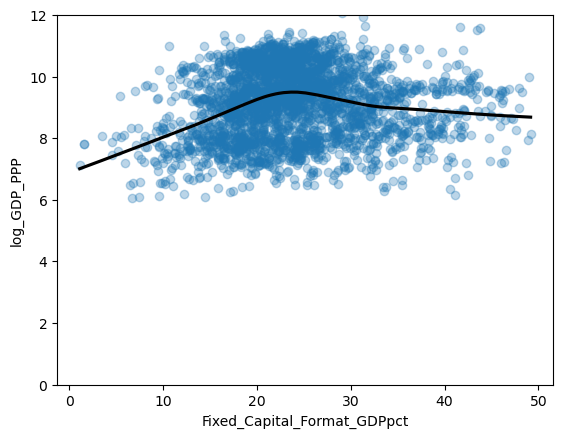

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

#Pct_with_electric_access
#Elec_squared
#Elec_cubed
#Rents_Commodity_Price_Index

sns.regplot(
    data=Development_df_filtered,
    x="Fixed_Capital_Format_GDPpct",
    y="log_GDP_PPP", 
    lowess=True,
    line_kws = {"color":"black"},
    scatter_kws={"alpha":0.3}
)

plt.ylim(0, 12)
plt.show()


In [214]:
Development_df_filtered.drop(
    columns=[
        #"log_PopGrowth",
        #"PopGrowth_squared",
        #"PopGrowth_cubed",
        #"sqrt_PopGrowth",
        #"recip_PopGrowth",
    ],
    inplace=True,
    errors="ignore"
)
#Mentions what variables to drop, ignoring errors

In [345]:
Development_df_filtered["PopGrowth_squared"] = (Development_df_filtered["Pop_Growth_Pct"]**2)
Development_df_filtered["PopGrowth_cubed"] = (Development_df_filtered["Pop_Growth_Pct"]**3)
Development_df_filtered['CapFormation_squared'] = (Development_df_filtered["Fixed_Capital_Format_GDPpct"]**2)
Development_df_filtered['log_GDP_PPP'] = np.log1p(Development_df_filtered["GDP_Per_Capita_PPP"])
Development_df_filtered['log_Agri'] = np.log1p(Development_df_filtered["Pct_in_Agriculture"])
Development_df_filtered['log_Energy'] = np.log1p(Development_df_filtered["Energy_Cons_Per_Cap"])
Development_df_filtered["log_Rents"] = np.log1p(Development_df_filtered["Resource_Rents_Pct_GDP"])
Development_df_filtered['EPop_squared'] = (Development_df_filtered["EPop_Pct"]**2)
Development_df_filtered['EPop_cubed'] = (Development_df_filtered["EPop_Pct"]**3)
Development_df_filtered['Rents_Energy'] = (Development_df_filtered["Resource_Rents_Pct_GDP"] * Development_df_filtered["Energy_Cons_Per_Cap"])
Development_df_filtered["PopGrowth_Dependency"] = (Development_df_filtered["Pop_Growth_Pct"] * Development_df_filtered["Dependency_Ratio"])
Development_df_filtered['Rents_Commodity_Price_Index'] = (Development_df_filtered["Resource_Rents_Pct_GDP"] * Development_df_filtered["Global_Commodity_Price_Index"])


#Development_df_filtered['PopGrowth_YrsSchooling'] = (Development_df_filtered["Pop_Growth_Pct"] * Development_df_filtered['Avg_Yrs_Schooling'])
#Development_df_filtered['PopGrowth_Urbanization'] = (Development_df_filtered["Pop_Growth_Pct"] * Development_df_filtered['Pct_urban_areas'])
Development_df_filtered['PopGrowth_FixedCapital'] = (Development_df_filtered["Pop_Growth_Pct"] * Development_df_filtered['Fixed_Capital_Format_GDPpct'])
Development_df_filtered.head()


#Creates all of the transformed variables

,index,Country,Year,Avg_Yrs_Schooling,Dependency_Ratio,Energy_Cons_Per_Cap,EPop_Pct,Fixed_Capital_Format_GDPpct,GDP_Per_Capita_PPP,Global_Commodity_Price_Index,HDI,Pct_in_Agriculture,Pct_urban_areas,Pop_Growth_Pct,Resource_Rents_Pct_GDP,Rule_of_Law_index,Trade_Pct_GDP,PopGrowth_squared,PopGrowth_cubed,CapFormation_squared,log_GDP_PPP,log_Agri,log_Energy,log_Rents,EPop_squared,EPop_cubed,Rents_Energy,PopGrowth_Dependency,Rents_Commodity_Price_Index,PopGrowth_FixedCapital
0,0,Albania,2000,8.750522,58.588726,6216.7456,49.528,34.040139,3977.793158,25.86253,0.682,50.467464,41.613583,-0.637357,1.205807,0.474,61.609260,0.406224,-0.258909,1158.731078,8.288734,3.940950,8.735163,0.791093,2453.022784,121493.312446,7496.192875,-37.341925,31.185209,-21.695715
1,1,Albania,2001,8.820000,57.827007,6383.7065,48.965,38.228045,4450.511351,-7.01529,0.691,49.435272,42.354515,-0.938470,0.774294,0.518,64.247444,0.880727,-0.826536,1461.383449,8.400999,3.920691,8.761661,0.573403,2397.571225,117397.075032,4942.868833,-54.268936,-5.431900,-35.875890
2,2,Albania,2002,8.885714,56.728830,7213.5920,48.945,38.575336,4840.358546,-0.77551,0.697,48.371387,43.152042,-0.299877,0.765809,0.515,65.991460,0.089926,-0.026967,1488.056534,8.484951,3.899371,8.883861,0.568609,2395.613025,117253.279509,5524.232955,-17.011654,-0.593892,-11.567844
3,3,Albania,2003,8.951428,55.605934,7441.4790,48.611,36.722128,5169.163145,17.50807,0.705,48.276344,44.029510,-0.374149,0.765832,0.511,64.823210,0.139988,-0.052376,1348.514716,8.550660,3.897444,8.914959,0.568622,2363.029321,114869.218323,5698.919769,-20.804914,13.408233,-13.739554
4,4,Albania,2004,9.017142,54.512900,8072.5440,48.121,36.331947,5594.816886,20.59162,0.710,47.916664,44.978493,-0.417931,0.868822,0.529,65.037940,0.174667,-0.072999,1320.010390,8.629775,3.890118,8.996348,0.625308,2315.630641,111430.462076,7013.600271,-22.782651,17.890443,-15.184261


In [346]:
Y = Development_df_filtered.log_GDP_PPP
X = Development_df_filtered.drop(['Year', 'Energy_Cons_Per_Cap', 'GDP_Per_Capita_PPP', 'Global_Commodity_Price_Index', 'HDI',
                                  'log_GDP_PPP', 'log_Agri', 'EPop_cubed', 'log_Rents'], axis = 1)

print(X.columns)

#This is the model that will fit for Y (Log GDP Per Capita at PPP)
#It has all the requisite transformations done, and is ready for a linear regression.



Y2 = Development_df_filtered.HDI
X2 = Development_df_filtered.drop(['Year', 'Avg_Yrs_Schooling', 'Energy_Cons_Per_Cap', 'GDP_Per_Capita_PPP',
                                   'Global_Commodity_Price_Index', 'HDI', 'Resource_Rents_Pct_GDP', 'log_GDP_PPP', 'log_Agri'], axis = 1)

print(X2.columns)

#This is the model that will fit for Y2 (HDI)
#It has all the requisite transformations done, and is ready for a linear regression.

Index(['index', 'Country', 'Avg_Yrs_Schooling', 'Dependency_Ratio', 'EPop_Pct',
       'Fixed_Capital_Format_GDPpct', 'Pct_in_Agriculture', 'Pct_urban_areas',
       'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index',
       'Trade_Pct_GDP', 'PopGrowth_squared', 'PopGrowth_cubed',
       'CapFormation_squared', 'log_Energy', 'EPop_squared', 'Rents_Energy',
       'PopGrowth_Dependency', 'Rents_Commodity_Price_Index',
       'PopGrowth_FixedCapital'],
      dtype='object')
Index(['index', 'Country', 'Dependency_Ratio', 'EPop_Pct',
       'Fixed_Capital_Format_GDPpct', 'Pct_in_Agriculture', 'Pct_urban_areas',
       'Pop_Growth_Pct', 'Rule_of_Law_index', 'Trade_Pct_GDP',
       'PopGrowth_squared', 'PopGrowth_cubed', 'CapFormation_squared',
       'log_Energy', 'log_Rents', 'EPop_squared', 'EPop_cubed', 'Rents_Energy',
       'PopGrowth_Dependency', 'Rents_Commodity_Price_Index',
       'PopGrowth_FixedCapital'],
      dtype='object')


In [123]:
X_ols = sm.add_constant(X)
#This line is essential for the Y-Intercept

model = sm.OLS(Y, X_ols).fit()

print(model.summary())


model.params
#This is the model for how certain variables affect GDP Per Capita (PPP)

#There are quite a few variables that are here, but there are also plenty that aren't here.
#Some notable ones are HDI, Output Per Hour (Specifically log Output), Liberal Democracy Index, and its quadratic term,
#Under 5 Mortality (Specifically the Log), Electricity Access (and its quadratic and cubic terms), Internet Access,
#Life Expectancy, along with its quadratic term, and private credit

#The reasons are as follows:
#HDI, and Output per hour effectively have GDP Per Capita involved in generating their values.
#HDI contains GNI Per Capita (PPP) in its formula, which is very similar to GDP Per Capita,
#And Output Per Hour is also effectively GDP Per Hour worked
#The Liberal Democracy Index is removed because it overlaps a lot with the Rule of Law Index, and is very strongly correlated,
#But without the actual concrete economic mechanisms that would link it to growth (Essentially, Rule of Law measures most of what the Liberal
#Democracy Index does, but with more, and including both would dampen both coefficients)
#U5 Mortality and life expectancy were both removed because they're effectively outcomes of a good economy. Typically a country will have
#higher life expectancy and lower child mortality because them becoming richer improves their healthcare systems
#Electricity Access and Internet Access were removed because they're both measurements of the quality of a country's technological capacity
#But are also more or less outcomes of growth. They both can have a causal effect, but the issue with using them is that a statistic that 
#says a country has high internet access or electricity access doesn't tell you how reliable those two are (people can have access, but be
#subject to blackouts). Additionally, energy consumption is likely better because it also tells you about technological capacity and 
#industrialization, but it tells you that a country has high quality infrastructure when they specifically are able to use a lot of energy
#as opposed to simply being able to use energy. Countries with blackouts will use less energy than they would if they didn't have them.
#Private Credit also suffers from reverse causality, as it can occur as a result of development, rather than causing it
#These variables in question mostly weren't in the final excel dataset used for this workbook, however, they were while I was working through
#the data. I removed them in order to have a dataset with more observations. This one ultimately has about 2900 observations, rather than the
#roughly 1900 observations in the original one I did



#Average years of schooling has a coefficient of 0.0363 which means that for every additional year of schooling that a country has on average,
#That their GDP Per Capita will be 3.63% higher (with a p-value below 0.05, meaning the effect is statistically significant,
#and not likely to have occurred by chance)

#Percent in Agriculture has a coefficient of -0.0097,
#which means that for every additional percent (the unit for this variable) of the population in agriculture, that GDP Per Capita decreases
#by 0.97%. This makes sense as a country with more people in agriculture is going to be less industrialized, and have a larger
#share of its population work in sectors with low value addition to their commodities.

#Urbanization has a coefficient of 0.0061, which means that for each additional percent of the population in urban areas,
#GDP Per Capita increases by 0.61%

#The Rule of Law Index has a coefficient of 0.4011, which means that for every unit that the index increases (which is only from 0 to 1),
#That GDP Per Capita increases by 40.11%. It going up by 0.1 (or 10%) means GDP Per Capita increases by 4.11%

#Trade as a % of GDP (or Trade Intensity) has a coefficient of -0.0006, meaning that each percent increase in trade intensity, GDP per Capita
#increases by 0.06%

#Dependency ratio is -0.0028, meaning that for each additional percent that the ratio of U15's and 65+'s to working age people increases
#GDP Per Capita decreases by 0.28%. Meanwhile, the PopGrowth*Dependency variable also has a negative effect, however, it is only
#significant at the 10% level, and not the 5% level. Regardless, population growth would have to be negative for this to have a positive 
#contribution to how dependency affects GDP

#For Epop Ratio (and any with quadratic specifications, the equation to determine the effect of a change in Employment/Population Ratio is:
#beta1(X) + beta2(X^2)
#The turning point where the marginal effect becomes zero comes when X = -(beta1)/(2*beta2).
#For EPop, that number is 0.0262/(2*0.000216), or 60.5556%. Below that number, the effect of EPop increasing is positive, but with diminishing
#returns. However, it becomes negative after reaching that point. 

#Resource rents as a percent of GDP have a coefficient of -6.494e-05 (each percent increase decreases GDP by 0.00649%),
#but the effect isn't statistically significant.
#However, Rents*Energy has a positive coefficient meaning that rents have a higher effect on GDP when a country uses more energy
#which essentially means that they have a higher effect when a country is more industrialized and has better infrastructure
#Assuming a resource rent% of 10% of GDP, and per capita energy consumption of 25,000 kWh, the effect of going from 25,000 to 50,000 kWh is:
#(8.148e-08 * 10*50,000) - (8.148e-08 * 10*25,000) = 0.02037, meaning that GDP per capita increases by 2.037% when energy consumption goes
#from 25,000 to 50,000 kWh per capita. Meanwhile, going from 10% to 20% of GDP in resource rents has the same 2.037% effect


#Fixed Capital Formation as a percent of GDP is another variable with a quadratic component, as well as an interaction component.
#The equation to determine the effect of a change in Fixed Capital Formation % on GDP Per Capita is beta1(X) + beta2(X^2) + beta3*PopGrowth*X
#First find the derivative: beta1 + 2beta2*x + beta3*PopGrowth, or 0.0135 - 0.0006426*X + 0.0029*PopGrowth
#Assuming no population growth, the point at which the marginal effect becomes zero is at the point 0.0135/0.0006426 = 21.0%. When population
#growth increases, this point will increase, and vice versa.

#For population growth rate, there are quite a few relevant terms
#These include the linear form popgrowth (not significant), popgrowth^2, popgrowth^3, popgrowth*dependency (not significant at the 5% level),
#and popgrowth*fixedcapital
#Therefore, the relevant ones are popgrowth^2, popgrowth^3, and popgrowth*fixedcapital
#Together, they look like this: beta1*PopGrowth^2 + beta2*PopGrowth^3 + beta3*PopGrowth*FixedCapital
#To find the marginal effect, take the derivative, which leaves you with -2*0.0252*PopGrowth + 3*0.0154*PopGrowth^2 + 0.0029*FixedCapital
#or -0.0504PopGrowth + 0.0462PopGrowth^2 + 0.0029*FixedCapital

#Assuming a fixed capital formation rate of roughly 20%, the formula becomes -0.0504PopGrowth + 0.0462PopGrowth^2 + 0.058. The resulting
#formula means there's essentially no point at which population growth has a negative effect on GDP Per Capita, as using the quadratic formula
#reveals that the solution involves imaginary numbers.


#For energy, the variable log_Energy has a coefficient of 0.3510, meaning that a 1% relative increase in energy
#(so 1000 to 1010, or 100000 to 101000) leads to a 0.3510% increase in GDP Per Capita. The interaction term means that this effect actually
#becomes stronger as countries have more resource intensive economies (Rents*Energy)




# - - - - - - - - > Policy Implications: < - - - - - - - -

#Based on the results below, it's clear that some variables have an unambiguously positive effect on economic output, such as average years
#of schooling, rule of law, increased energy consumption, and urbanization.

#Other variables exhibit diminishing returns, like fixed capital formation, which starts to be a drag on GDP once it constitutes 21% of GDP.
#This means that investing too much into capital can start to take away from other areas, of which consumption is often one, or that each
#additional unit of fixed capital just adds less value to economic output.

#The effect of a high dependency ratio on GDP is negative, and is worse the faster the population grows

#Population growth also had a very complex relationship with GDP which depended on dependency ratios,
#and vice versa for dependency ratio itself.

#Resource rents also didn't have as much of an effect as I assumed they would, especially with respect to the rents*commodity price index
#interaction term, which I thought would be a more significant variable.

#Trade also had a statistically significant (negative) effect on economic output, but not an economically significant one. Based on this 
#alone, increasing trade intensity from 0% to 100% has almost no effect on GDP (all else equal). However, in practice, all else isn't equal


#The data also predictably showed that urbanization, and moving out of agriculture both have positive effects on a country's economic output
#because agriculture jobs don't add much value to the economy, and schooling is far worse in those areas,
#meaning that human capital accumulation is far more limited. Meanwhile, in urban areas, people can more easily access adequate education,
#have better opportunities to find (and train for) higher skilled jobs that pay better wages,
#and more urbanized countries have fewer logistical issues with respect to connecting everyone to their major population centers
#However, increasing urbanization too much can lead to people living in poor conditions which can facilitate the rapid spread of disease,
#which can cause public health crises. Additionally, just living in an urban area doesn't mean you'll get access to high quality schooling
#Therefore, policies aimed at moving people into urban areas, coupled with increased investment in housing, school construction, and public
#health are very important in order to increase everyone's potential to find gainful, high skilled employment, and to ensure that the
#downsides of moving to urban areas are mitigated.


#Therefore, the main things to target are increased pathways towards moving people into urban areas, increased investment in housing,
#schooling and general infrastructure to withstand the pressure that urbanization can put on urban areas.
#Increasing fixed capital investment also helps (up to a point) and can provide easier 
#opportunities to access gainful employment that people often don't have in overburdened urban areas, or rural areas.
#Improving the rule of law in a country can help make people far more willing to engage in entrepreneurial activity due to increased trust
#in the country's economic system, which is a crucial part of a capitalist economy
#Lastly, energy consumption has a very significant effect on economic output, and it's obviously very important for energy to be in abundant
#supply to facilitate such activities. However, since global temperatures are increasing in spite of the fact that many regions aren't fully
#industrialized and urbanized, it becomes far more important for an increasing share of that energy to come through renewable resources
#and low carbon energy sources (Nuclear, wind, solar, etc).


                            OLS Regression Results                            
Dep. Variable:            log_GDP_PPP   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     1477.
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:58:53   Log-Likelihood:                -1074.2
No. Observations:                2926   AIC:                             2188.
Df Residuals:                    2906   BIC:                             2308.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

const                          4.645128e+00
Avg_Yrs_Schooling              3.633509e-02
Dependency_Ratio              -2.763930e-03
EPop_Pct                       2.616514e-02
Fixed_Capital_Format_GDPpct    1.348347e-02
Pct_in_Agriculture            -9.652780e-03
Pct_urban_areas                6.143378e-03
Pop_Growth_Pct                -2.660897e-02
Resource_Rents_Pct_GDP        -6.493867e-05
Rule_of_Law_index              4.011496e-01
Trade_Pct_GDP                 -6.133341e-04
PopGrowth_squared             -2.519324e-02
PopGrowth_cubed                1.539221e-02
CapFormation_squared          -3.213269e-04
log_Energy                     3.510055e-01
EPop_squared                  -2.163874e-04
Rents_Energy                   8.147811e-08
PopGrowth_Dependency          -9.041263e-04
Rents_Commodity_Price_Index    2.454451e-05
PopGrowth_FixedCapital         2.930758e-03
dtype: float64

In [190]:
X2_ols = sm.add_constant(X2)
#This line is essential for the Y-Intercept

model2 = sm.OLS(Y2, X2_ols).fit()

print(model2.summary())

#This is the model for how certain variables affect HDI (Human Development Index)

#There are quite a few variables that are here, but there are also plenty that aren't here, for the same reasons as with GDP Per Capita.
#Some notable ones are HDI, Output Per Hour (Specifically log Output), Liberal Democracy Index, and its quadratic term,
#Under 5 Mortality (Specifically the Log), Electricity Access (and its quadratic and cubic terms), Internet Access,
#Life Expectancy, along with its quadratic term, as well as private credit. Average years of schooling was also added because it is a 
#fundamental component of HDI. For fairly obvious reasons, it's a very strong correlate with education and therefore quality of life, and 
#increasing it increases HDI, and would do so even if HDI didn't include an education component because it is very important to increasing
#economic output.

#The variables that have no effect on HDI are popgrowth^2 and rents*Commodity price index





#The effect of dependency ratio on HDI is -0.0012 meaning that a 1% unit (percent) increase in dependency ratio decreases HDI by 0.0012, and
#The popgrowth*dependency interaction term only amplifies that effect (assuming popgrowth>0)

#For Epop Ratio (and any with cubic specifications, the equation to determine the effect of a change in Employment/Population Ratio is:
#beta1(X) + beta2(X^2) + beta3(X^3), or -0.0064X + 0.00014X^2 -8.608e-07X^3
#First take the derivative, leaving you with -2.5824e-06*X^2 + 0.00028X - 0.0064
#The point where the marginal effect is positive comes when X is between 32.7491 and 75.6782, while EPop ratio has a negative effect on HDI
#when X is outside of that range

#Trade as a percent of GDP has a coefficient of -6.444e-05, meaning that for each unit (percent) increase in trade intensity, HDI decreases
#by 6.444e-05. This means that increasing trade intensity by even 100% would only decrease HDI by 0.0064, all else equal.

#For the rule of law index, the coefficient is 0.0449, which means that for a one unit increase in the rule of law index (which is the entire
#0 to 1 range of the index), HDI increases by 0.0449. Increasing the rule of law index by 0.05 (5%) increases HDI by 0.002245,
#increasing it by 0.1 (10%) increases it by 0.00449

#Urbanization has a coefficient of 0.0009, meaning that for each percent increase in urbanization, HDI increases by 0.0009.
#This means that urbanization has a strong independent impact on HDI, and the same is the case with the percent in agriculture, but -0.0008
#instead.

#To find the effect that fixed capital formation has on GDP, the terms are beta1*X + beta2*X^2 + beta3*PopGrowth*X, or
#0.0028*X - 6.204e-05*X^2 + 0.0005*X*PopGrowth
#The marginal effect is 0.0028 - 0.000121*X + 0.0005*PopGrowth
#Given 2% population growth, and 20% fixed capital formation, going to 21% fixed capital formation increases HDI by 0.001259
#Meanwhile, going from 50% to 51% decreases HDI by 0.002371
#Given 2% population growth, the turning point at which increasing fixed capital has a negative effect on HDI is:
#0.0028 + 0.001 - 1.21e-04 * x = 0, or 31.40%. When population growth increases, the point at which increasing fixed capital has a negative
#effect increases. At 0% growth, that point is 23.14%, at 3% growth, that point is 35.53%

#Population growth has a relevant effect on HDI at many different levels. To find the marginal effect, take the derivative of:
#beta1*X + beta2*X^3 + beta3*X*Dependency + beta4*X*FixedCapital
#leaving you with: -0.0186 + 0.003X^2 - 0.0002*Dependency + 0.0005*FixedCapital
#Assuming a 50% dependency ratio, & a 25% fixed capital formation rate, an increase in population growth by 1%, affects HDI as follows:
#-0.0186 + 0.003 -0.0002*50 + 0.0005*25 = -0.0131, meaning in that context, a 1% increase in population ratio decreases HDI by 0.0131 units
#If the dependency ratio is higher, then it has a more negative effect, and if fixed capital formation is higher, then the effect is mitigated

#The relevant variables to find the effect of Resource Rents on HDI are the logged specification,
#as well as the Rents*Energy interaction term
#To find the effect of increasing rents by 1% (in relative terms), first take the derivative, which leaves you with
#-0.0091/Rents - 2.288e-08*Energy. A 1% increase in rents means:
#(-0.0091/Rents - 2.288e-08*Energy) * (0.01*Rents) = -0.000091 - 2.288e-10*Rents*Energy. At high energy consumption levels, the latter term
#actually becomes quite significant, albeit only to make the effect more negative

#The relevant variables to find the effect of Energy Consumption on HDI are the logged specification,
#as well as the Rents*Energy interaction term
#To find the effect of increasing Energy Consumption by 1% (in relative terms), first take the derivative, which leaves you with
#0.0538/Energy - 2.288e-08*Rents. A 1% increase in Energy Consumption means:
#(0.0538/Energy - 2.288e-08*Rents) * (0.01*Energy) = 0.000538 - 2.288e-10*Energy*Rents, with the term - 2.288e-10*Energy*Rents only having a
#modest effect even when resource rents get to 10% of GDP and energy consumption at 50,000 kWh. There, the effect becomes:
#0.000538 - 2.288e-10*50000*10 = 0.0004236, meaning a 1% increase in energy increases HDI by 0.0004236, which can stack up very quickly, given
#how high energy consumption levels can get



model2.params









# - - - - - - - - > Policy Implications: < - - - - - - - -

#Based on the results below, it's clear that some variables have an unambiguously positive effect on HDI, such as energy consumption,
#increased rule of law, and urbanization

#Trade intensity has a negative effect on HDI, but very slight

#Employment population ratio, and capital formation have a positive effect on HDI but exhibit diminishing returns, eventually having a
#negative effect. In the case of Employment Population Ratio, this may come from too many old/young people, or pregnant/disabled people working.
#When it comes to fixed capital formation, it may come from taking money away from people for expenditures in favor of investment.
#of schooling, rule of law, inreased energy consumption, and increased credit to the private sector.

#Population growth has a very complex effect on HDI.

#A higher share of people in agriculture has a strongly negative effect on HDI, as does a higher dependency ratio,
#and a more resource intensive economy


#Similarly to the GDP model, the main things to target are increased pathways towards moving people into urban areas, as well as increased
#rule of law. Therefore, there remains
#a need to increase investment in housing, schooling, and infrastructure, to limit the strain that urbanization puts on urban areas.

#Increasing fixed capital investment helps to a point (albeit, the HDI model says that fixed capital investment can have a negative effect at
#a lower percent rate) by giving opportunities to access gainful employment
#Improving the rule of law in a country can help HDI both because it makes people more willing to engage in entrepreneurial activity due to
#increased trust in the country's economic system, which is a crucial part of a capitalist economy, and also because it can lead to improved
#public administration, better law enforcement, and improved justice, along with less public sector corruption
#Like with GDP, energy consumption has a very significant effect on economic growth, and it's obviously very important for energy to be in
#abundant supply to facilitate such activities. However, since global temperatures are increasing in spite of the fact that many regions 
#aren't fully industrialized and urbanized yet, it becomes far more important for an increasing share of that energy to come through 
#renewable resources and low carbon energy sources (Nuclear, wind, solar, etc).

                            OLS Regression Results                            
Dep. Variable:                    HDI   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     1895.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:43:19   Log-Likelihood:                 4977.0
No. Observations:                2926   AIC:                            -9914.
Df Residuals:                    2906   BIC:                            -9794.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

const                          3.079775e-01
Dependency_Ratio              -1.233209e-03
EPop_Pct                      -6.395456e-03
Fixed_Capital_Format_GDPpct    2.790354e-03
Pct_in_Agriculture            -8.411584e-04
Pct_urban_areas                9.385545e-04
Pop_Growth_Pct                -1.855772e-02
Rule_of_Law_index              4.486069e-02
Trade_Pct_GDP                 -6.444326e-05
PopGrowth_squared              2.442193e-04
PopGrowth_cubed                1.005207e-03
CapFormation_squared          -6.203774e-05
log_Energy                     5.382812e-02
log_Rents                     -9.132277e-03
EPop_squared                   1.407461e-04
EPop_cubed                    -8.608197e-07
Rents_Energy                  -2.288154e-08
PopGrowth_Dependency          -1.665300e-04
Rents_Commodity_Price_Index    5.000174e-06
PopGrowth_FixedCapital         5.058878e-04
dtype: float64

In [11]:
import statsmodels.api as sm

# Keep only complete observations
df = Development_df_filtered[['Dependency_Ratio', 'Pop_Growth_Pct']].dropna()

X_Ex = sm.add_constant(df['Dependency_Ratio'])
y_Ex = df['Pop_Growth_Pct']

model = sm.OLS(y_Ex, X_Ex).fit()

print(model.summary())

#When a variable has an effect contrary to what I'd expect, I plugged it with a similar variable to see how much they correlated
#Especially when they both ran in the opposite direction. Afterwards, if the R^2 is high, it means that the two variables may be strongly
#Correlated

                            OLS Regression Results                            
Dep. Variable:         Pop_Growth_Pct   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     2717.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:55:54   Log-Likelihood:                -3710.7
No. Observations:                2926   AIC:                             7425.
Df Residuals:                    2924   BIC:                             7437.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.6014      0.057  

In [192]:
#Linear Regression Data Science Model Code GDP Per Capita (PPP)

In [12]:
from sklearn.model_selection import train_test_split

In [337]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 17)
#80/20 data split with GDP Per Capita (PPP). Random state 17 basically prevents the model from giving different resutls based on
#random sampling

#X train and Y train are the 80% of the data that is used for training, and X & Y test are the 20% used for the model testing
#Y test contains the actual values of Y in that 20%, while Y pred is trying to use X test to project what Y values would be for that 20%

In [14]:
X_train.shape, Y_train.shape
#Trained Data

((2340, 19), (2340,))

In [15]:
X_test.shape, Y_test.shape
#Data For Testing

((586, 19), (586,))

In [46]:
from sklearn import linear_model
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

#Linear regression model imports

In [17]:
model = linear_model.LinearRegression()
#Linear regression

In [18]:
model.fit(X_train, Y_train)
#Building the training model

LinearRegression()

In [19]:
Y_pred = model.predict(X_test)
#Applies trained model to make a prediction on the test set

In [51]:
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Y_train_pred = model.predict(X_train)

print('Coefficient of determination (R^2) for training data: %.4f' % r2_score(Y_train, Y_train_pred))
#R^2 based on the training data, essentially the values of Y based on the training data, vs the predictions of the training data using X_train
print('Root mean squared error (RMSE) for training data: %.4f'
      % root_mean_squared_error(Y_train, Y_train_pred))
#Root mean squared error also based on the training data

print('Coefficient of determination (R^2) for test data: %.4f'
      % r2_score(Y_test, Y_pred))
#R^2 based on the test data, essentially the values of Y based on the test data, vs the predictions of the test data using X_test
print('Root mean squared error (RMSE) for test data: %.4f'
      % root_mean_squared_error(Y_test, Y_pred))


#This gives the coefficients from the 80% train data, as well as other relevant numbers like the R^2 and the RMSE value. It also does the
#same with the 20% test data, and the two returned similar values for both R^2 and RMSE.


#The numbers here (for the training model) are by and large within about 10% of the actual coefficients from the OLS regression based on 
#all of the data, with dependency Ratio being the main exception. However, the model itself gave similar results to the OLS model in terms 
#of its R2. That said, some of the variables that aren't statistically significant have far different values from the values in the regression

                       Variable   Coefficient
0             Avg_Yrs_Schooling  3.611643e-02
1              Dependency_Ratio -3.759083e-03
2                      EPop_Pct  2.953259e-02
3   Fixed_Capital_Format_GDPpct  1.463259e-02
4            Pct_in_Agriculture -9.716297e-03
5               Pct_urban_areas  6.059929e-03
6                Pop_Growth_Pct -2.658764e-02
7        Resource_Rents_Pct_GDP  7.741420e-04
8             Rule_of_Law_index  4.573712e-01
9                 Trade_Pct_GDP -7.192971e-04
10            PopGrowth_squared -2.324028e-02
11              PopGrowth_cubed  1.585601e-02
12         CapFormation_squared -3.221283e-04
13                   log_Energy  3.420904e-01
14                 EPop_squared -2.444745e-04
15                 Rents_Energy  7.535419e-08
16         PopGrowth_Dependency -8.047209e-04
17  Rents_Commodity_Price_Index  2.262566e-06
18       PopGrowth_FixedCapital  2.489663e-03
Coefficients: [ 3.61164348e-02 -3.75908297e-03  2.95325926e-02  1.46325894e-02
 

In [37]:
test_model = LinearRegression()
test_model.fit(X_test, Y_test)

test_coef_df = pd.DataFrame({
    'Variable': X_test.columns,
    'Coefficient': test_model.coef_
})

print(test_coef_df)


#These are the values for the GDP regression from the 20% test data
#When it comes to the variables average years of schooling, percent in agricultural areas, percent in urban areas, log(Energy),
#and the squared capital formation term, the linear regression from the train and test models are quite similar, usually within about 10%
#while for the squared and cubed population growth terms, the two are within about 20-30% of the actual terms
#For the remaining variables and interactions, the discrepancies are quite significant, with many coefficients being about half as large,
#or twice as large as the values from the original OLS model, and the training model
#However, in most of the cases, the signs didn't change. The difference between the coefficient magnitudes may come down to
#differences between the data in the training and testing samples

                       Variable   Coefficient
0             Avg_Yrs_Schooling  3.894388e-02
1              Dependency_Ratio  8.374234e-04
2                      EPop_Pct  1.249532e-02
3   Fixed_Capital_Format_GDPpct  6.124036e-03
4            Pct_in_Agriculture -9.402663e-03
5               Pct_urban_areas  6.681743e-03
6                Pop_Growth_Pct -2.942141e-02
7        Resource_Rents_Pct_GDP -3.354523e-03
8             Rule_of_Law_index  1.864100e-01
9                 Trade_Pct_GDP -1.968075e-04
10            PopGrowth_squared -3.202772e-02
11              PopGrowth_cubed  1.264453e-02
12         CapFormation_squared -2.848409e-04
13                   log_Energy  3.775183e-01
14                 EPop_squared -1.015537e-04
15                 Rents_Energy  1.308865e-07
16         PopGrowth_Dependency -1.265828e-03
17  Rents_Commodity_Price_Index  6.559717e-05
18       PopGrowth_FixedCapital  4.786174e-03


In [204]:
#Linear Regression Data Science Model Code (HDI)

In [338]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=17)
#80/20 data split with HDI

In [28]:
X2_train.shape, Y2_train.shape
#Trained Data

((2340, 19), (2340,))

In [29]:
X2_test.shape, Y2_test.shape
#Data For Testing

((586, 19), (586,))

In [30]:
model2 = linear_model.LinearRegression()
#Linear regression

In [31]:
model2.fit(X2_train, Y2_train)
#Building the training model

LinearRegression()

In [32]:
Y2_pred = model2.predict(X2_test)
#Applies trained model to make a prediction on the test set

In [54]:
coefficients = pd.DataFrame({
    'Variable': X2.columns,
    'Coefficient': model2.coef_
})

print(coefficients)

print('Coefficients:', model2.coef_)
print('Intercept:', model2.intercept_)

Y2_train_pred = model2.predict(X2_train)

print('Coefficient of determination (R^2) for training data: %.4f' % r2_score(Y2_train, Y2_train_pred))
#R^2 based on the training data
print('Root mean squared error (RMSE) for training data: %.4f'
      % root_mean_squared_error(Y2_train, Y2_train_pred))

print('Coefficient of determination (R^2) for test data: %.4f'
      % r2_score(Y2_test, Y2_pred))
print('Root mean squared error (RMSE) for test data: %.4f'
      % root_mean_squared_error(Y2_test, Y2_pred))




#This gives the coefficients from the 80% train data, as well as other relevant numbers like the R^2 and the RMSE value. It also does the
#same with the 20% test data, and the two return similar values for both R^2 and RMSE.


#The numbers here are by and large within about 10% of the actual coefficients from the OLS regression based on all of the data, with
#Dependency Ratio being the main exception. However, the model itself gave similar results to the OLS model in terms of its R2
#That said, some of the variables that aren't statistically significant have far different values from the values in the regression

                       Variable   Coefficient
0              Dependency_Ratio -1.268384e-03
1                      EPop_Pct -6.213356e-03
2   Fixed_Capital_Format_GDPpct  2.622563e-03
3            Pct_in_Agriculture -8.672641e-04
4               Pct_urban_areas  9.129704e-04
5                Pop_Growth_Pct -1.779679e-02
6             Rule_of_Law_index  4.685534e-02
7                 Trade_Pct_GDP -5.788230e-05
8             PopGrowth_squared  8.600885e-04
9               PopGrowth_cubed  7.918441e-04
10         CapFormation_squared -5.584800e-05
11                   log_Energy  5.389417e-02
12                    log_Rents -9.231553e-03
13                 EPop_squared  1.408897e-04
14                   EPop_cubed -8.764790e-07
15                 Rents_Energy -2.298303e-08
16         PopGrowth_Dependency -1.485813e-04
17  Rents_Commodity_Price_Index  6.279438e-06
18       PopGrowth_FixedCapital  4.418889e-04
Coefficients: [-1.26838418e-03 -6.21335558e-03  2.62256308e-03 -8.67264056e-04
 

In [38]:
test_model2 = LinearRegression()
test_model2.fit(X2_test, Y2_test)

test2_coef_df = pd.DataFrame({
    'Variable': X2_test.columns,
    'Coefficient': test_model2.coef_
})

print(test2_coef_df)



#These are the values for the HDI regression from the 20% test data.
#Unlike the prior 20% test data model for GDP, for this one, the vast majority of variables with statistically significant effects in the OLS
#regression are within at least 30% of the values from the 80% train data, and many of them are within 10% of the values from the train data.
#In most of the cases, the signs didn't change, and the difference between coefficient magnitudes is generally pretty small.

                       Variable   Coefficient
0              Dependency_Ratio -1.127297e-03
1                      EPop_Pct -8.019212e-03
2   Fixed_Capital_Format_GDPpct  3.243000e-03
3            Pct_in_Agriculture -6.779053e-04
4               Pct_urban_areas  1.100298e-03
5                Pop_Growth_Pct -2.418118e-02
6             Rule_of_Law_index  3.390134e-02
7                 Trade_Pct_GDP -9.803137e-05
8             PopGrowth_squared -2.440571e-03
9               PopGrowth_cubed  2.123543e-03
10         CapFormation_squared -8.368907e-05
11                   log_Energy  5.400089e-02
12                    log_Rents -9.141792e-03
13                 EPop_squared  1.551024e-04
14                   EPop_cubed -8.777341e-07
15                 Rents_Energy -2.340791e-08
16         PopGrowth_Dependency -2.430607e-04
17  Rents_Commodity_Price_Index  8.428391e-08
18       PopGrowth_FixedCapital  8.294034e-04


In [214]:
import seaborn as sns

In [215]:
Y_test

498      8.902694
278      7.952624
1243     7.957233
1752    10.181748
1830     8.672069
          ...    
1059     9.644266
767      6.103752
1545     8.337648
1435    10.113702
2213    10.411531
Name: log_GDP_PPP, Length: 586, dtype: float64

In [216]:
import numpy as np
#np.array(Y_test)

#This and the 2 functions below (for both GDP and HDI) are put as comments
#because the outputs are very long and make the notebook harder to work around

In [217]:
#Y_pred

In [218]:
#np.array(Y_pred)

Text(0, 0.5, 'Predicted Log GDP Per Capita PPP')

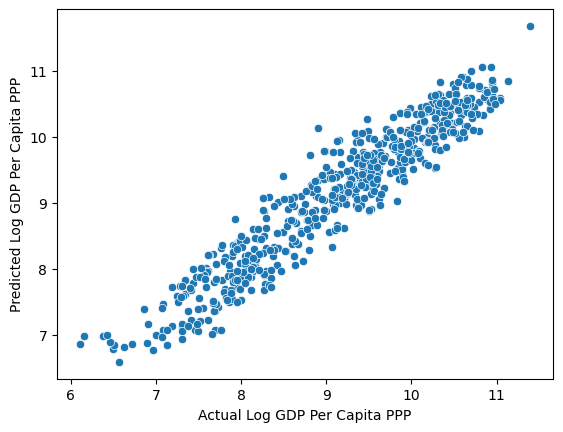

In [219]:
sns.scatterplot(x=Y_test, y=Y_pred)

plt.xlabel("Actual Log GDP Per Capita PPP")
plt.ylabel("Predicted Log GDP Per Capita PPP")

#This and the 2 visualizations below are the visualizations for the actual log values of GDP, vs the predicted log values

Text(0, 0.5, 'Predicted Log GDP Per Capita PPP')

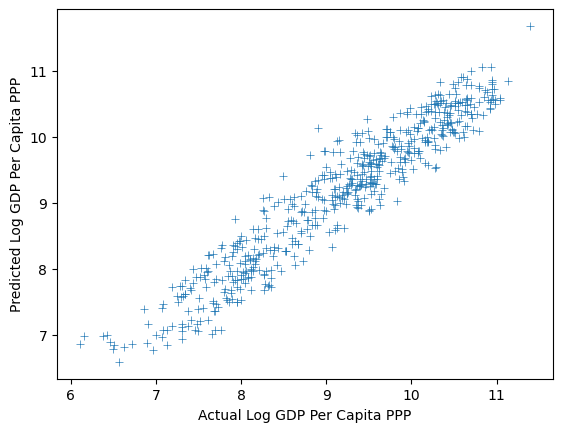

In [220]:
sns.scatterplot(x=Y_test, y=Y_pred, marker="+")

plt.xlabel("Actual Log GDP Per Capita PPP")
plt.ylabel("Predicted Log GDP Per Capita PPP")

Text(0, 0.5, 'Predicted Log GDP Per Capita PPP')

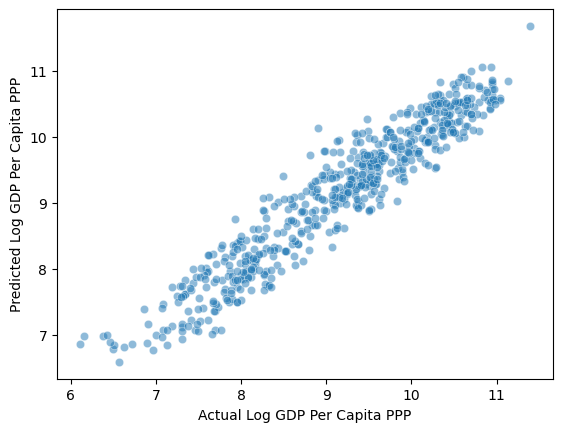

In [221]:
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.5)

plt.xlabel("Actual Log GDP Per Capita PPP")
plt.ylabel("Predicted Log GDP Per Capita PPP")

In [222]:
Y2_test

498     0.661
278     0.510
1243    0.534
1752    0.807
1830    0.553
        ...  
1059    0.727
767     0.391
1545    0.599
1435    0.847
2213    0.824
Name: HDI, Length: 586, dtype: float64

In [223]:
#np.array(Y2_test)

In [224]:
#Y2_pred

In [225]:
#np.array(Y2_pred)

Text(0, 0.5, 'Predicted HDI')

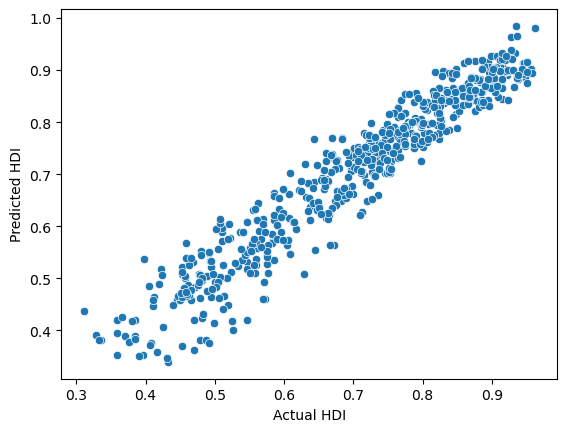

In [226]:
sns.scatterplot(x=Y2_test, y=Y2_pred)

plt.xlabel("Actual HDI")
plt.ylabel("Predicted HDI")

#This and the 2 visualizations below are the visualizations for the actual values of HDI, vs the predicted values

Text(0, 0.5, 'Predicted HDI')

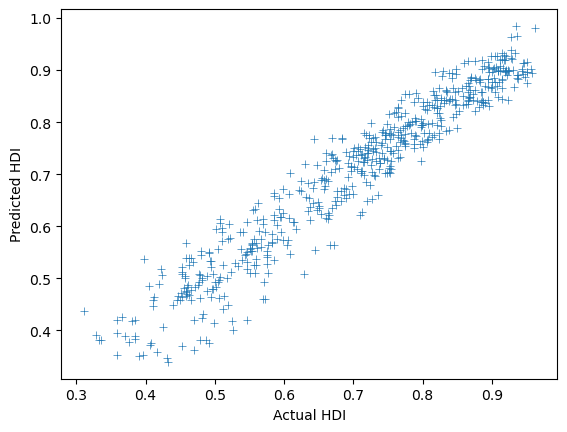

In [227]:
sns.scatterplot(x=Y2_test, y=Y2_pred, marker="+")

plt.xlabel("Actual HDI")
plt.ylabel("Predicted HDI")

Text(0, 0.5, 'Predicted HDI')

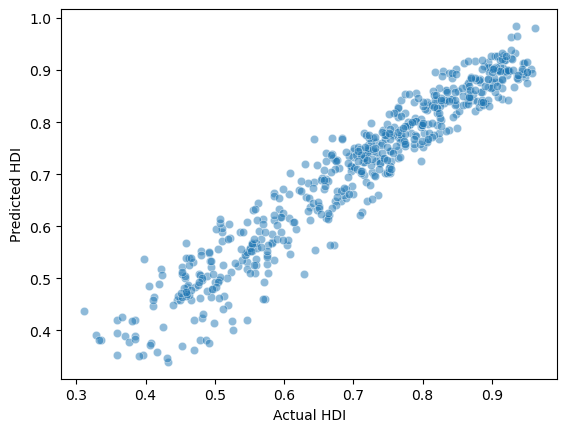

In [228]:
sns.scatterplot(x=Y2_test, y=Y2_pred, alpha=0.5)

plt.xlabel("Actual HDI")
plt.ylabel("Predicted HDI")

In [132]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score


#These are the imports for the second part, which is to see what affects HDI and GDP
#As opposed to the first part, which was linear regression, this part is about gradient boosting


In [131]:
from tqdm import tqdm
from contextlib import contextmanager
import joblib

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback

#This is a function used to tell how much progress has been made on each of the hyperparameter grids, because they take a long time to run
#It's helpful to know whether you need to fix it to make it take less time, even for randomizedsearchcv

#You put this at the end
#with tqdm_joblib(tqdm(total=600)): #or whatever the total is
#    random.fit(X_train, y_train)

In [231]:
Development_df_filtered.columns

Index(['Country', 'Year', 'Avg_Yrs_Schooling', 'Dependency_Ratio',
       'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
       'GDP_Per_Capita_PPP', 'Global_Commodity_Price_Index', 'HDI',
       'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct',
       'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP',
       'log_GDP_PPP', 'PopGrowth_squared', 'PopGrowth_cubed',
       'CapFormation_squared', 'log_Agri', 'log_Energy', 'log_Rents',
       'EPop_squared', 'EPop_cubed', 'Rents_Energy', 'PopGrowth_Dependency',
       'Rents_Commodity_Price_Index', 'PopGrowth_FixedCapital'],
      dtype='object')

In [347]:
y2 = Development_df_filtered['HDI']
X2 = Development_df_filtered[['Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
                              'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas',
                              'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']]


y = Development_df_filtered['log_GDP_PPP']
X = Development_df_filtered[['Avg_Yrs_Schooling', 'Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
                             'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 
                             'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']]

#This defines all of the variables as being part of X or Y.
#For this part, I made GDP Per Capita (PPP) Y_orig and the non-transformed variables X_Orig,
#along with making log GDP Y, and the non-transformed variables X for the model, and I made HDI Y2, and the non-transformed variables X2 
#However, I omitted the same variables that I did from the OLS models.
#I compared X, and Y, to X_orig, and Y_orig to see which one performed better in terms of RMSE, R2, and cross_val_score, and since
#the log transformed model performed considerably better in all of them, I went with it instead of the non-transformed Y

In [348]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 17)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

#This function is the same as its counterpart for the linear regression component

((2340, 12), (586, 12), (2340,), (586,))

In [227]:
gbr = GradientBoostingRegressor(random_state=17)
#This line makes the gradient boosting regression model (there exists a classification model, to answer questions like how likely someone is
#to make the hall of fame based on their career stats)

In [228]:
gbr.fit(X_train, y_train)
#This trains the gradient boosting model on X & Y's respective training data

GradientBoostingRegressor(random_state=17)

In [229]:
y_pred = gbr.predict(X_test)

#This makes predictions for the 20% of data that the model hasn't seen

In [230]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
#Imports the tools to find MAE, MSE, RMSE and R2, lower is better for the first 3

In [231]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2:", r2_score(y_test, y_pred))

print("RMSE:", root_mean_squared_error(y_test, y_pred))

print("Cross Validation Score:", cross_val_score(gbr, X_train, y_train, cv=3, n_jobs=-1).mean())


#Mean absolute error is the average of the differences between the actual and predicted value, mean squared error is the average of the
#squared differences between the actual and predicted values, RMSE is just the square root of that value, and R2 is the proportion of the
#variation in y that comes from changes in x.

MAE: 0.16677208033171262
MSE: 0.04496077597907147
R2: 0.9639385996670047
RMSE: 0.21203956229692483


Exception ignored in: <function ResourceTracker.__del__ at 0x110fd1c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1072f5c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102a25c60>
Traceback (most rece

Cross Validation Score: 0.9595283032085159


In [239]:
#Development_df_filtered.corr(numeric_only=True)['log_GDP_PPP'].sort_values(ascending=False)
#This gives the correlation between log GDP per Capita and all of the variables (many aren't actually used for this part)

#I put the function as a comment because it takes up a lot of space

In [233]:
param_grid = {
    'n_estimators': [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000],
    'learning_rate': [0.001, 0.01, 0.02, 0.025, 0.03, 0.04, 0.05, 0.06, 0.07, 0.075, 0.08, 0.09, 0.1],
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [2, 3, 4, 5, 6, 7, 8],
    'subsample': [0.3, 0.4, 0.5, 0.6, 0.7],
    'max_features': [None, 'sqrt', 'log2']
}

#This parameter grid searches for the best of all of these features
#The N-estimators refers to the number of decision trees, the learning rate refers to the rate at which the model essentially adapts to new
#information. Lower rates mean it won't adapt much to values that differ from the rest, and high rates mean it may overcorrect in response
#Max depth is the number of levels down in the decision tree

In [234]:
random_grid = RandomizedSearchCV(estimator=gbr, param_distributions=param_grid, n_iter=200, cv=3, scoring='r2', n_jobs=-1, random_state=17, verbose=5)

# number of random combinations

In [235]:
with tqdm_joblib(tqdm(total=600)):
    random_grid.fit(X_train, y_train)

print(random_grid.best_params_)
print(random_grid.best_score_)

#This gives the best parameters from the hyperparameter grid, and the code at the top is to show progress at different points of time to 
#essentially give you info ahead of time on how long it'll take to be fully finished.
#It mentions 3 folds for the 200 candidates, meaning there are 600 fits on the model

  0%|                                                   | 0/600 [00:00<?, ?it/s]

Fitting 3 folds for each of 200 candidates, totalling 600 fits


100%|█████████████████████████████████████████| 600/600 [39:48<00:00,  1.76s/it]

{'subsample': 0.4, 'n_estimators': 12000, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 5, 'learning_rate': 0.01}
0.9869689149959053


In [349]:
param_grid_final = {
    'n_estimators': [12000],
    'learning_rate': [0.0025, 0.005, 0.0075, 0.01],
    'max_depth': [5],
    'min_samples_split': [2],
    'min_samples_leaf': [5],
    'subsample': [0.4],
    'max_features': [None]
}

#This is the final model after I got everything else to work. I simply wanted to go further to see what the best learning rate was, I used a 
#gridsearchcv in spite of its longer computational time because it's only 12 fits, which as the function shows a couple lines below
#only took about 2 minutes.

In [350]:
grid_final = GridSearchCV(estimator=gbr, param_grid=param_grid_final, cv=3, scoring='r2', n_jobs=-1, verbose=5)
#These are the conditions for the grid search, it firstly uses gridsearchcv, the estimator is the same gradient boosting regression from
#before, the parameter grid is the final one, the model runs 3 cross vals, it uses r2 scoring, the verbose is 5 so that it tells you some 
#stuff while running the model

In [351]:
with tqdm_joblib(tqdm(total=12)):
    grid_final.fit(X_train, y_train)
#12 here represents 4*3 (CVs)

print(grid_final.best_params_)
print(grid_final.best_score_)


%|                                                    | 0/12 [00:00<?, ?it/s]

Fitting 3 folds for each of 4 candidates, totalling 12 fits



%|███▋                                        | 1/12 [00:44<08:12, 44.77s/it]
%|███████████                                 | 3/12 [00:45<01:45, 11.73s/it]
%|█████████████████████████▋                  | 7/12 [00:45<00:19,  3.82s/it]
%|█████████████████████████████▎              | 8/12 [00:58<00:15,  3.82s/it]
%|█████████████████████████████████           | 9/12 [01:20<00:24,  8.22s/it]
%|███████████████████████████████████▊       | 10/12 [01:20<00:13,  6.70s/it]
  5%|██▏                                     | 32/600 [06:20<1:52:41, 11.90s/it]


{'learning_rate': 0.0075, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 12000, 'subsample': 0.4}
0.9870924634911203


In [239]:
import joblib

joblib.dump(random_grid, "GDP_randomized_search.pkl")
joblib.dump(grid_final, "GDP_final_grid.pkl")
#This is used to save the GDP randomized search so you don't have to run the code for 40 minutes again

['GDP_final_grid.pkl']

In [352]:
best_gbr = grid_final.best_estimator_
print(best_gbr)

#This shows the best parameter values and uses it for subsequent functions

GradientBoostingRegressor(learning_rate=0.0075, max_depth=5, min_samples_leaf=5,
                          n_estimators=12000, random_state=17, subsample=0.4)


In [353]:
y_test_pred = best_gbr.predict(X_test)

y_train_pred = best_gbr.predict(X_train)

#This predicts y values for the training and testing datasets which are ultimately compared to the actual values to give you values for
#the validity of the training and testing data.
#Both are used to see if the model suffers from overfitting

In [242]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("R²:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

#This looks at the model strength in the training and testing model and compares R2 to check for overfitting, which didn't happen in this
#dataset

MAE: 0.06919767318638202
MSE: 0.009397736327780194
R²: 0.9924624180842038
RMSE: 0.09694192244730962
Train R²: 0.999958093293143
Test R²: 0.9924624180842038


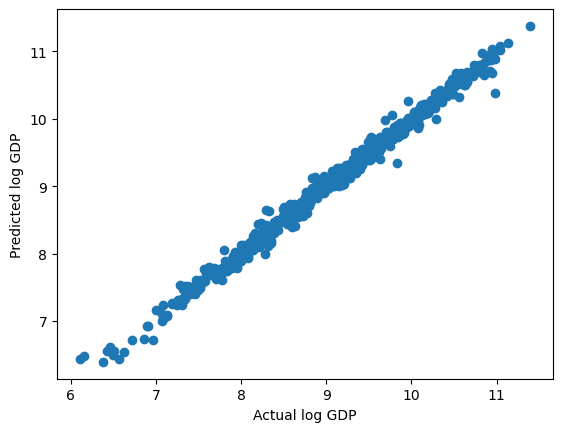

In [243]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual log GDP")
plt.ylabel("Predicted log GDP")
plt.show()

#This is a plot of actual vs predicted log GDP

In [384]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=17)

train_idx, test_idx = next(gss.split(X, y, groups=Development_df_filtered["Country"]))

X_train_group = X.iloc[train_idx]
X_test_group = X.iloc[test_idx]

y_train_group = y.iloc[train_idx]
y_test_group = y.iloc[test_idx]


#This is for a group shuffle split, which is when it splits data into two different groups but based on the country. So all of the US'
#observations are in one group, not both, which means it's less likely to exhibit data leakage

In [385]:
print(set(X_train_group.index) & set(X_test_group.index))

set()


In [387]:
gbr_group = GradientBoostingRegressor(
    learning_rate=0.0075,
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=12000,
    subsample=0.4,
    random_state=17
)


gbr_group.fit(X_train_group, y_train_group)

#This uses the hyperparameters from the prior model to make the new gradient boosting model, which is used to find the feature importance 

GradientBoostingRegressor(learning_rate=0.0075, max_depth=5, min_samples_leaf=5,
                          n_estimators=12000, random_state=17, subsample=0.4)

In [388]:
y_group_pred = gbr_group.predict(X_test_group)

print("R²:", r2_score(y_test_group, y_group_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_group, y_group_pred)))
print("MAE:", mean_absolute_error(y_test_group, y_group_pred))

#This is used to find model strength for the GSS model

R²: 0.9456890727537711
RMSE: 0.27462992681019244
MAE: 0.2151848946023767


In [389]:
importance = pd.DataFrame({
    "Variable (GDP Model)": X.columns,
    "Importance (GDP Model)": gbr_group.feature_importances_
}).sort_values("Importance (GDP Model)", ascending=False)

importance

#This is the importance for each variable in affecting the dependent variable, based on gbr_group, or the group shuffle split

,Variable (GDP Model),Importance (GDP Model)
2,Energy_Cons_Per_Cap,0.699802
6,Pct_in_Agriculture,0.154929
7,Pct_urban_areas,0.026930
3,EPop_Pct,0.023748
1,Dependency_Ratio,0.017360
0,Avg_Yrs_Schooling,0.015425
9,Resource_Rents_Pct_GDP,0.013708
5,Global_Commodity_Price_Index,0.012855
10,Rule_of_Law_index,0.011894
8,Pop_Growth_Pct,0.009813


In [390]:
gbr_group_all_data = GradientBoostingRegressor(
    learning_rate=0.0075,
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=12000,
    subsample=0.4,
    random_state=17
)


gbr_group_all_data.fit(X_train_group, y_train_group)

#The purpose of this and the subsequent functions is to be able to apply the model to all of the data points so I can get predicted values 
#for the entire sample, instead of the 20%

GradientBoostingRegressor(learning_rate=0.0075, max_depth=5, min_samples_leaf=5,
                          n_estimators=12000, random_state=17, subsample=0.4)

In [391]:
X_all_group = X[X_train_group.columns]
#This reordered the columns from X, making a new X without overriding the X column from throughout all of the models
y_all_pred = gbr_group_all_data.predict(X_all_group)

print(X_all_group.columns.equals(X_train_group.columns))

print(X_train_group.columns.tolist())
print(X_all_group.columns.tolist())

#The 3 print statements first confirm whether the X columns are in the same order, and the last 2 give each of the columns (they're all in 
#the same order)

True
['Avg_Yrs_Schooling', 'Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct', 'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']
['Avg_Yrs_Schooling', 'Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct', 'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']


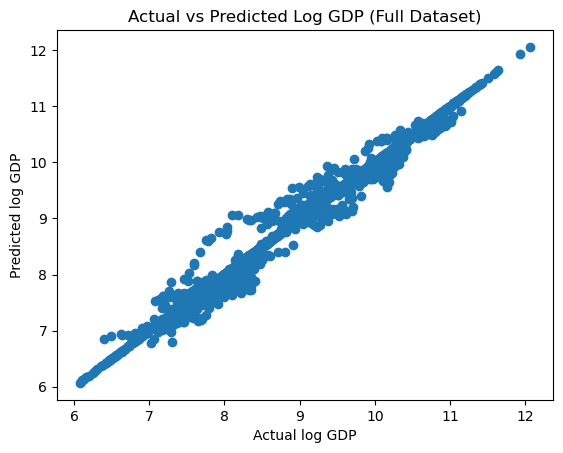

In [392]:
plt.scatter(y, y_all_pred)

plt.xlabel("Actual log GDP")
plt.ylabel("Predicted log GDP")

plt.title("Actual vs Predicted Log GDP (Full Dataset)")

plt.show()

In [393]:
print("Full Dataset R²:", r2_score(y, y_all_pred))
print("Full Dataset RMSE:", np.sqrt(mean_squared_error(y, y_all_pred)))

Full Dataset R²: 0.9884293194338563
Full Dataset RMSE: 0.12264364526300743


In [341]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 17)
X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape

((2340, 11), (586, 11), (2340,), (586,))

In [342]:
gbr2 = GradientBoostingRegressor()

In [343]:
gbr2.fit(X2_train, y2_train)

GradientBoostingRegressor()

In [272]:
y2_pred = gbr2.predict(X2_test)

#test vs prediction shows how accurate the model is

In [257]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
#Imports the tools to find MAE, MSE, and R2, lower is better for the first 2

In [329]:
print("MAE:", mean_absolute_error(y2_test, y2_pred))

print("MSE:", mean_squared_error(y2_test, y2_pred))

print("R2:", r2_score(y2_test, y2_pred))

print("RMSE:", root_mean_squared_error(y2_test, y2_pred))

print("Cross Validation Score:", cross_val_score(gbr2, X2_train, y2_train, cv=3, n_jobs=-1).mean())

MAE: 0.02126746099128548
MSE: 0.0007713828842040979
R2: 0.9694335518479967
RMSE: 0.027773780516956958
Cross Validation Score: 0.9640962331950615


In [ ]:
#Development_df_filtered.corr(numeric_only=True)['HDI'].sort_values(ascending=False)
#This gives the correlation between HDI and all of the variables (many aren't actually used for this part)

#I put the function as a comment because it takes up a lot of space

In [330]:
param_grid2 = {
    'n_estimators': [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000],
    'learning_rate': [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.02, 0.025, 0.03, 0.04, 0.05, 0.06, 0.07, 0.075, 0.08, 0.09, 0.1],
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [2, 3, 4, 5, 6, 7, 8],
    'subsample': [0.3, 0.4, 0.5, 0.6, 0.7],
    'max_features': [None, 'sqrt', 'log2']
}

In [331]:
random_grid2 = RandomizedSearchCV(estimator=gbr2, param_distributions=param_grid2, n_iter=200, cv=3, scoring='r2', n_jobs=-1, random_state=17, verbose=5)

In [416]:
with tqdm_joblib(tqdm(total=600)):
    random_grid2.fit(X2_train, y2_train)

print(random_grid2.best_params_)
print(random_grid2.best_score_)

  0%|                                                   | 0/600 [00:00<?, ?it/s]

Fitting 3 folds for each of 200 candidates, totalling 600 fits


100%|█████████████████████████████████████████| 600/600 [42:08<00:00,  2.33s/it]

{'subsample': 0.5, 'n_estimators': 16000, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 8, 'learning_rate': 0.0075}
0.9886650811753941


100%|█████████████████████████████████████████| 600/600 [45:40<00:00,  4.57s/it]


['HDI_randomized_search.pkl']

In [417]:
param_grid2_final = {
    'n_estimators': [16000],
    'learning_rate': [0.0075],
    'max_depth': [8, 9, 10, 11, 12],
    'min_samples_split': [6],
    'min_samples_leaf': [5],
    'subsample': [0.5],
    'max_features': ['log2']
}

In [418]:
grid2_final = GridSearchCV(estimator=gbr2, param_grid=param_grid2_final, cv=3, scoring='r2', n_jobs=-1, verbose=5)

In [419]:
with tqdm_joblib(tqdm(total=15)):
    grid2_final.fit(X2_train, y2_train)
#15 here represents 5*3 (CVs)

print(grid2_final.best_params_)
print(grid2_final.best_score_)


%|                                                    | 0/15 [00:00<?, ?it/s]

Fitting 3 folds for each of 5 candidates, totalling 15 fits



%|██▉                                         | 1/15 [00:38<08:54, 38.21s/it]
%|█████▊                                      | 2/15 [00:38<03:28, 16.07s/it]
%|████████▊                                   | 3/15 [00:38<01:45,  8.79s/it]
%|███████████▋                                | 4/15 [00:41<01:11,  6.51s/it]
%|██████████████▋                             | 5/15 [00:42<00:43,  4.31s/it]
%|█████████████████▌                          | 6/15 [00:42<00:26,  2.98s/it]
%|████████████████████▌                       | 7/15 [00:45<00:23,  2.99s/it]
%|███████████████████████▍                    | 8/15 [00:46<00:15,  2.19s/it]
%|██████████████████████████▍                 | 9/15 [01:52<02:11, 21.86s/it]
%|████████████████████████████▋              | 10/15 [02:13<01:49, 21.90s/it]
%|███████████████████████████████▌           | 11/15 [02:13<01:01, 15.29s/it]
%|██████████████████████████████████▍        | 12/15 [02:26<00:43, 14.54s/it]
%|█████████████████████████████████████▎     | 13/15 [02:31<00:

{'learning_rate': 0.0075, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 16000, 'subsample': 0.5}
0.9887033162924815


In [420]:
import joblib

joblib.dump(random_grid2, "HDI_randomized_search.pkl")
joblib.dump(grid2_final, "HDI_final_grid.pkl")

['HDI_final_grid.pkl']

In [421]:
best_gbr2 = grid2_final.best_estimator_
print(best_gbr2)

GradientBoostingRegressor(learning_rate=0.0075, max_depth=10,
                          max_features='log2', min_samples_leaf=5,
                          min_samples_split=6, n_estimators=16000,
                          subsample=0.5)


In [422]:
y2_test_pred = best_gbr2.predict(X2_test)

y2_train_pred = best_gbr2.predict(X2_train)

In [423]:
print("MAE:", mean_absolute_error(y2_test, y2_test_pred))
print("MSE:", mean_squared_error(y2_test, y2_test_pred))
print("R²:", r2_score(y2_test, y2_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, y2_test_pred)))

print("Train R²:", r2_score(y2_train, y2_train_pred))
print("Test R²:", r2_score(y2_test, y2_test_pred))

MAE: 0.0087013397704096
MSE: 0.00016364664962027225
R²: 0.9935154163602836
RMSE: 0.012792445021194043
Train R²: 0.9999999994339915
Test R²: 0.9935154163602836


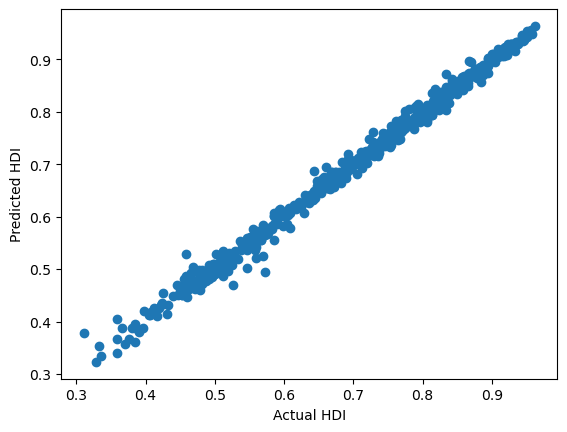

In [424]:
import matplotlib.pyplot as plt

plt.scatter(y2_test, y2_test_pred)
plt.xlabel("Actual HDI")
plt.ylabel("Predicted HDI")
plt.show()

In [426]:
from sklearn.model_selection import GroupShuffleSplit

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=17)

train_idx_2, test_idx_2 = next(gss2.split(X2, y2, groups=Development_df_filtered["Country"]))

X2_train_group = X2.iloc[train_idx_2]
X2_test_group = X2.iloc[test_idx_2]

y2_train_group = y2.iloc[train_idx_2]
y2_test_group = y2.iloc[test_idx_2]

In [427]:
print(set(X2_train_group.index) & set(X2_test_group.index))

set()


In [428]:
gbr2_group = GradientBoostingRegressor(
    learning_rate=0.0075,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=6,
    n_estimators=16000,
    subsample=0.5,
    random_state=17
)

gbr2_group.fit(X2_train_group, y2_train_group)

[CV 3/3] END learning_rate=0.01, max_depth=6, max_features=None, min_samples_leaf=3, min_samples_split=3, n_estimators=9000, subsample=0.4;, score=0.987 total time=  37.7s
[CV 1/3] END learning_rate=0.0075, max_depth=7, max_features=log2, min_samples_leaf=4, min_samples_split=3, n_estimators=11000, subsample=0.4;, score=0.988 total time=  18.8s
[CV 1/3] END learning_rate=0.001, max_depth=8, max_features=log2, min_samples_leaf=5, min_samples_split=6, n_estimators=12000, subsample=0.3;, score=0.985 total time=  20.1s
[CV 2/3] END learning_rate=0.025, max_depth=2, max_features=None, min_samples_leaf=6, min_samples_split=8, n_estimators=22000, subsample=0.7;, score=0.983 total time= 1.1min
[CV 1/3] END learning_rate=0.1, max_depth=3, max_features=None, min_samples_leaf=8, min_samples_split=4, n_estimators=14000, subsample=0.7;, score=0.984 total time= 1.0min
[CV 1/3] END learning_rate=0.075, max_depth=2, max_features=log2, min_samples_leaf=6, min_samples_split=3, n_estimators=11000, subsam

Exception ignored in: <function ResourceTracker.__del__ at 0x106739c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV 1/3] END learning_rate=0.03, max_depth=7, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=6000, subsample=0.6;, score=0.988 total time=  42.7s
[CV 1/3] END learning_rate=0.025, max_depth=5, max_features=None, min_samples_leaf=4, min_samples_split=2, n_estimators=21000, subsample=0.7;, score=0.987 total time= 2.0min
[CV 1/3] END learning_rate=0.06, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=11000, subsample=0.5;, score=0.986 total time=  18.4s
[CV 3/3] END learning_rate=0.06, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=11000, subsample=0.5;, score=0.986 total time=  18.1s
[CV 2/3] END learning_rate=0.08, max_depth=6, max_features=None, min_samples_leaf=7, min_samples_split=6, n_estimators=8000, subsample=0.3;, score=0.988 total time=  25.9s
[CV 1/3] END learning_rate=0.08, max_depth=2, max_features=sqrt, min_samples_leaf=6, min_samples_split=7, n_estimators=20000, subsample=

Exception ignored in: <function ResourceTracker.__del__ at 0x105425c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV 1/3] END learning_rate=0.01, max_depth=6, max_features=None, min_samples_leaf=3, min_samples_split=3, n_estimators=9000, subsample=0.4;, score=0.988 total time=  37.3s
[CV 3/3] END learning_rate=0.06, max_depth=5, max_features=None, min_samples_leaf=6, min_samples_split=8, n_estimators=11000, subsample=0.7;, score=0.987 total time=  58.4s
[CV 2/3] END learning_rate=0.075, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=5, n_estimators=16000, subsample=0.3;, score=0.984 total time=  32.5s
[CV 1/3] END learning_rate=0.005, max_depth=3, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=6000, subsample=0.3;, score=0.975 total time=   5.7s
[CV 3/3] END learning_rate=0.005, max_depth=3, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=6000, subsample=0.3;, score=0.973 total time=   5.0s
[CV 2/3] END learning_rate=0.005, max_depth=7, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=20000, subsampl

Exception ignored in: <function ResourceTracker.__del__ at 0x102931c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV 2/3] END learning_rate=0.01, max_depth=6, max_features=None, min_samples_leaf=3, min_samples_split=3, n_estimators=9000, subsample=0.4;, score=0.989 total time=  37.7s
[CV 2/3] END learning_rate=0.0075, max_depth=7, max_features=log2, min_samples_leaf=4, min_samples_split=3, n_estimators=11000, subsample=0.4;, score=0.989 total time=  19.0s
[CV 2/3] END learning_rate=0.001, max_depth=8, max_features=log2, min_samples_leaf=5, min_samples_split=6, n_estimators=12000, subsample=0.3;, score=0.985 total time=  20.7s
[CV 3/3] END learning_rate=0.025, max_depth=2, max_features=None, min_samples_leaf=6, min_samples_split=8, n_estimators=22000, subsample=0.7;, score=0.982 total time= 1.1min
[CV 2/3] END learning_rate=0.1, max_depth=3, max_features=None, min_samples_leaf=8, min_samples_split=4, n_estimators=14000, subsample=0.7;, score=0.984 total time= 1.0min
[CV 3/3] END learning_rate=0.08, max_depth=6, max_features=None, min_samples_leaf=7, min_samples_split=6, n_estimators=8000, subsampl

Exception ignored in: <function ResourceTracker.__del__ at 0x103161c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


GradientBoostingRegressor(learning_rate=0.0075, max_depth=10,
                          min_samples_leaf=5, min_samples_split=6,
                          n_estimators=16000, random_state=17, subsample=0.5)

In [429]:
y2_group_pred = gbr2_group.predict(X2_test_group)

print("R²:", r2_score(y2_test_group, y2_group_pred))
print("RMSE:", np.sqrt(mean_squared_error(y2_test_group, y2_group_pred)))
print("MAE:", mean_absolute_error(y2_test_group, y2_group_pred))

R²: 0.9049270441462725
RMSE: 0.05231753433702163
MAE: 0.04199191468180725


In [430]:
importance2 = pd.DataFrame({
    "Variable (HDI Model)": X2.columns,
    "Importance (HDI Model)": gbr2_group.feature_importances_
}).sort_values("Importance (HDI Model)", ascending=False)

importance2


,Variable (HDI Model),Importance (HDI Model)
1,Energy_Cons_Per_Cap,0.716304
5,Pct_in_Agriculture,0.140222
0,Dependency_Ratio,0.056514
9,Rule_of_Law_index,0.029648
6,Pct_urban_areas,0.016174
7,Pop_Growth_Pct,0.013040
8,Resource_Rents_Pct_GDP,0.009363
2,EPop_Pct,0.008081
10,Trade_Pct_GDP,0.004607
3,Fixed_Capital_Format_GDPpct,0.004088


In [431]:
gbr2_group_all_data = GradientBoostingRegressor(
    learning_rate=0.0075,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=6,
    n_estimators=16000,
    subsample=0.5,
    random_state=17
)


gbr2_group_all_data.fit(X2_train_group, y2_train_group)

[CV 2/3] END learning_rate=0.03, max_depth=7, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=6000, subsample=0.6;, score=0.989 total time=  42.7s
[CV 3/3] END learning_rate=0.0075, max_depth=7, max_features=log2, min_samples_leaf=4, min_samples_split=3, n_estimators=11000, subsample=0.4;, score=0.988 total time=  20.3s
[CV 1/3] END learning_rate=0.025, max_depth=2, max_features=None, min_samples_leaf=6, min_samples_split=8, n_estimators=22000, subsample=0.7;, score=0.982 total time= 1.1min
[CV 2/3] END learning_rate=0.005, max_depth=3, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=6000, subsample=0.3;, score=0.975 total time=   5.3s
[CV 1/3] END learning_rate=0.005, max_depth=7, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=20000, subsample=0.7;, score=0.988 total time=  59.2s
[CV 1/3] END learning_rate=0.04, max_depth=7, max_features=sqrt, min_samples_leaf=3, min_samples_split=5, n_estimators=23000, subsam

Exception ignored in: <function ResourceTracker.__del__ at 0x10358dc60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV 3/3] END learning_rate=0.03, max_depth=7, max_features=None, min_samples_leaf=3, min_samples_split=8, n_estimators=6000, subsample=0.6;, score=0.987 total time=  42.6s
[CV 2/3] END learning_rate=0.025, max_depth=5, max_features=None, min_samples_leaf=4, min_samples_split=2, n_estimators=21000, subsample=0.7;, score=0.988 total time= 2.0min
[CV 3/3] END learning_rate=0.1, max_depth=3, max_features=None, min_samples_leaf=8, min_samples_split=4, n_estimators=14000, subsample=0.7;, score=0.985 total time= 1.0min
[CV 2/3] END learning_rate=0.005, max_depth=2, max_features=None, min_samples_leaf=6, min_samples_split=5, n_estimators=3000, subsample=0.5;, score=0.962 total time=   6.4s
[CV 1/3] END learning_rate=0.04, max_depth=6, max_features=None, min_samples_leaf=3, min_samples_split=3, n_estimators=9000, subsample=0.7;, score=0.987 total time=  51.9s
[CV 1/3] END learning_rate=0.01, max_depth=5, max_features=None, min_samples_leaf=6, min_samples_split=4, n_estimators=6000, subsample=0.

Exception ignored in: <function ResourceTracker.__del__ at 0x105399c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV 1/3] END learning_rate=0.06, max_depth=5, max_features=None, min_samples_leaf=6, min_samples_split=8, n_estimators=11000, subsample=0.7;, score=0.986 total time=  56.8s
[CV 3/3] END learning_rate=0.001, max_depth=8, max_features=log2, min_samples_leaf=5, min_samples_split=6, n_estimators=12000, subsample=0.3;, score=0.985 total time=  20.8s
[CV 1/3] END learning_rate=0.075, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=5, n_estimators=16000, subsample=0.3;, score=0.984 total time=  30.8s
[CV 3/3] END learning_rate=0.075, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=5, n_estimators=16000, subsample=0.3;, score=0.983 total time=  32.9s
[CV 3/3] END learning_rate=0.005, max_depth=7, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=20000, subsample=0.7;, score=0.988 total time=  58.8s
[CV 1/3] END learning_rate=0.08, max_depth=6, max_features=None, min_samples_leaf=7, min_samples_split=6, n_estimators=8000, subsam

Exception ignored in: <function ResourceTracker.__del__ at 0x1068bdc60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV 2/3] END learning_rate=0.06, max_depth=5, max_features=None, min_samples_leaf=6, min_samples_split=8, n_estimators=11000, subsample=0.7;, score=0.988 total time=  55.0s
[CV 3/3] END learning_rate=0.025, max_depth=5, max_features=None, min_samples_leaf=4, min_samples_split=2, n_estimators=21000, subsample=0.7;, score=0.987 total time= 2.1min
[CV 2/3] END learning_rate=0.06, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=11000, subsample=0.5;, score=0.986 total time=  18.3s
[CV 3/3] END learning_rate=0.04, max_depth=7, max_features=sqrt, min_samples_leaf=3, min_samples_split=5, n_estimators=23000, subsample=0.7;, score=0.987 total time=  22.9s
[CV 3/3] END learning_rate=0.001, max_depth=2, max_features=None, min_samples_leaf=4, min_samples_split=2, n_estimators=5000, subsample=0.7;, score=0.945 total time=  14.1s
[CV 1/3] END learning_rate=0.075, max_depth=4, max_features=sqrt, min_samples_leaf=8, min_samples_split=5, n_estimators=15000, subsamp

Exception ignored in: <function ResourceTracker.__del__ at 0x106771c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


GradientBoostingRegressor(learning_rate=0.0075, max_depth=10,
                          min_samples_leaf=5, min_samples_split=6,
                          n_estimators=16000, random_state=17, subsample=0.5)

In [432]:
X2_all_group = X2[X2_train_group.columns]
#This reordered the columns from X2, making a new X2 without overriding the X2 column from throughout all of the models
y2_all_pred = gbr2_group_all_data.predict(X2_all_group)

print(X2_all_group.columns.equals(X2_train_group.columns))

print(X2_train_group.columns.tolist())
print(X2_all_group.columns.tolist())

#The 3 print statements first confirm whether the X2 columns are in the same order, and the last 2 give each of the columns (they're all in 
#the same order)

True
['Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct', 'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']
['Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct', 'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']


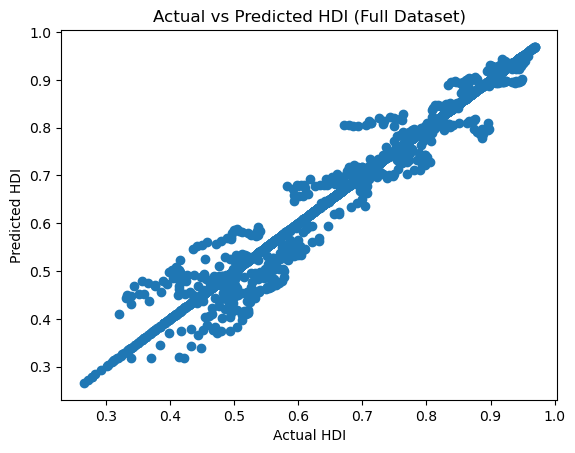

In [433]:
plt.scatter(y2, y2_all_pred)

plt.xlabel("Actual HDI")
plt.ylabel("Predicted HDI")

plt.title("Actual vs Predicted HDI (Full Dataset)")

plt.show()

In [177]:
print("Full Dataset R²:", r2_score(y2, y2_all_pred))
print("Full Dataset RMSE:", np.sqrt(mean_squared_error(y2, y2_all_pred)))

Full Dataset R²: 0.9779723773824767
Full Dataset RMSE: 0.023982454612595783


In [193]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import xgboost as xgb
import shap
#I used xgboost for modelling and used shap to understand how the model works.

In [223]:
# Features
y = Development_df_filtered['log_GDP_PPP']
X = Development_df_filtered[['Avg_Yrs_Schooling', 'Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
                             'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 
                             'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']]

print(Development_df_filtered.columns.tolist())



#For X, I took all of the nonlinear transformations that existed in the original regression model,
#and replaced them with their linear variables, as I did with the gradient boosting
#This included keeping Energy_Cons_Per_Cap, 'Resource_Rents_Pct_GDP', and 'Global_Commodity_Price_Index'

# Target
y = Development_df_filtered.log_GDP_PPP




print(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)


xgb_model = xgb.XGBRegressor(
    random_state=17
)

param_grid_SHAP = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.4, 0.5, 0.6],
    'colsample_bytree': [0.8, 0.9, 1.0]
}



grid_search_SHAP = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP.fit(X_train, y_train)

['Year', 'Avg_Yrs_Schooling', 'Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct', 'GDP_Per_Capita_PPP', 'Global_Commodity_Price_Index', 'HDI', 'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP', 'log_GDP_PPP', 'PopGrowth_squared', 'PopGrowth_cubed', 'CapFormation_squared', 'log_Agri', 'log_Energy', 'log_Rents', 'EPop_squared', 'EPop_cubed', 'Rents_Energy', 'PopGrowth_Dependency', 'Rents_Commodity_Price_Index', 'PopGrowth_FixedCapital', 'Country']
Index(['Avg_Yrs_Schooling', 'Dependency_Ratio', 'Energy_Cons_Per_Cap',
       'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
       'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas',
       'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index',
       'Trade_Pct_GDP'],
      dtype='object')


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.4, 0.5, 0.6]},
             scoring='neg_root_mean_squared_error')

In [198]:
print(grid_search_SHAP.best_params_)
print(grid_search_SHAP.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.6}
-0.14522109916342296


In [199]:
param_grid_SHAP_new = {
    'n_estimators': [300, 400, 500, 600, 700, 800, 900, 1000],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.075, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.8]
}



grid_search_SHAP_new = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP_new, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP_new.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.075, 0.1, 0.2],
                         'max_depth': [5, 6, 7],
                         'n_estimators': [300, 400, 500, 600, 700, 800, 900,
                                          1000],
                         'subsample': [0.6, 0.7, 0.8]},
             scoring='neg_root_mean_squared_error')

In [200]:
print(grid_search_SHAP_new.best_params_)
print(grid_search_SHAP_new.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.075, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.7}
-0.13569146120845002


In [201]:
param_grid_SHAP_3 = {
    'n_estimators': [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000],
    'max_depth': [5],
    'learning_rate': [0.075],
    'subsample': [0.7],
    'colsample_bytree': [0.8]
}



grid_search_SHAP_3 = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP_3, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP_3.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8], 'learning_rate': [0.075],
                         'max_depth': [5],
                         'n_estimators': [1000, 1500, 2000, 2500, 3000, 3500,
                                          4000, 4500, 5000],
                         'subsample': [0.7]},
             scoring='neg_root_mean_squared_error')

In [202]:
print(grid_search_SHAP_3.best_params_)
print(grid_search_SHAP_3.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.075, 'max_depth': 5, 'n_estimators': 5000, 'subsample': 0.7}
-0.1352191352001787


In [203]:
param_grid_SHAP_last = {
    'n_estimators': [5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000],
    'max_depth': [5],
    'learning_rate': [0.075],
    'subsample': [0.7],
    'colsample_bytree': [0.8]
}



grid_search_SHAP_last = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP_last, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP_last.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8], 'learning_rate': [0.075],
                         'max_depth': [5],
                         'n_estimators': [5000, 6000, 7000, 8000, 9000, 10000,
                                          11000, 12000, 13000, 14000, 15000,
                                          16000, 17000, 18000, 19000, 20000,
                                          21000, 22000, 23000, 24000, 25000,
                                          26000, 27000, 28000, 29000, 30000],
                         'subsample': [0.7]},
             scoring='neg_root_mean_squared_error')

In [204]:
print(grid_search_SHAP_last.best_params_)
print(grid_search_SHAP_last.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.075, 'max_depth': 5, 'n_estimators': 28000, 'subsample': 0.7}
-0.13521372611935212


In [205]:
best_model_SHAP = grid_search_SHAP_last.best_estimator_
print(best_model_SHAP)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.075, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=28000,
             n_jobs=None, num_parallel_tree=None, ...)


In [398]:
explainer = shap.Explainer(best_model_SHAP)

X_SHAP = X[X_train_group.columns]

print(X_SHAP.columns.equals(X_train_group.columns))

shap_values = explainer(X_SHAP)

#Here I could've done X_test, which is the standard one, but since I already made the model for the train test split,
#I just wanted to do it for all of them because then the SHAP will give me values for all of the ~2900 country year values
#Here I used X_SHAP as the basis for SHAP values so it would align the column order as opposed to just X,
#which may've had a different column order

True


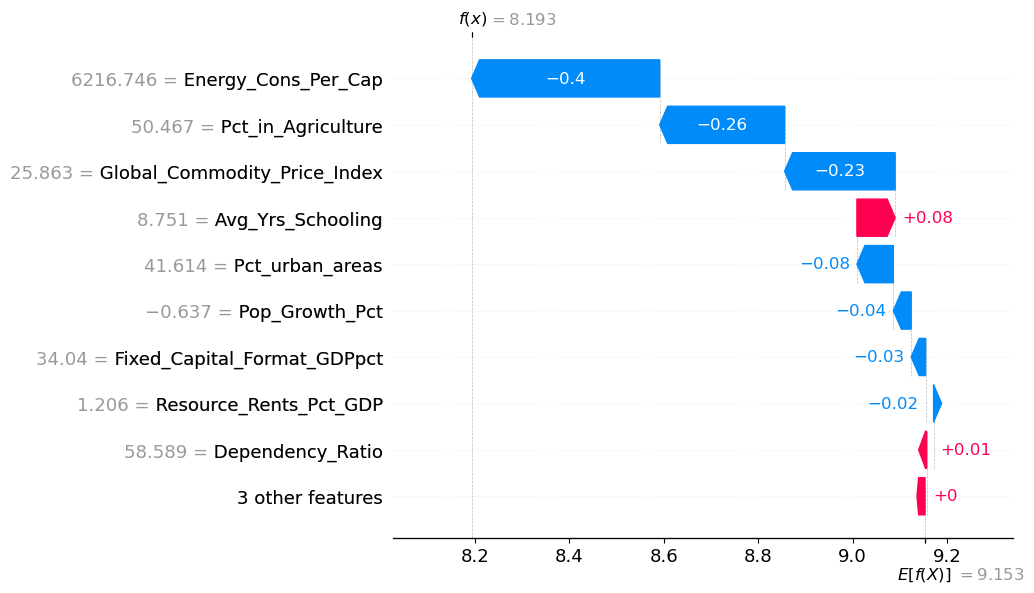

Country    Albania
Year          2000
Name: 0, dtype: object

In [395]:
shap.plots.waterfall(shap_values[0])
Development_df_filtered.loc[X_SHAP.index[0], ['Country', 'Year']]


#This is a waterfall plot for how the variables from the model affect the ln(GDP Per Capita) of a country year observation
#In this case, that's Albania in 2000.
#Predictably, energy consumption is the primary driver of the discrepancy between the baseline value
#(9.153 for all observations, which corresponds to a GDP Per Capita PPP of $9,443), and the
#actual value, 8.193 (Which corresponds to a GDP Per Capita of $3,615)

#However, it's important to note that f(x) isn't actually the log(GDP Per Capita), it's the SHAP modeled one, in reality, the value is 8.289
#and the GDP Per Capita is $3,979



#Here, this gives us the effect that each of these have on economic outcomes. It'll go one of a few ways, the value for the variable
#is above the sample average and that has a positive effect on log(GDP), or vice versa (indicating a variable with a negative effect on GDP)
#or the value is below the sample average and that has a negative effect on log(GDP), or vice versa (indicating that the variable in question
#has a negative effect on GDP)

#Here energy consumption is below average, and that has a negative effect on GDP, meaning that higher energy consumption leads to a higher GDP
#Here there are more people in agriculture than average, and that also has a negative effect, meaning that more people in agriculture
#is a drag on the economy
#In this year, the commodity price index change (the variable is expressed as a percent change relative to the prior year)
#is well above average, which has a negative effect, meaning that there's actually a negative correlation between it and GDP
#Here, years of schooling is above average, and it has a positive effect on GDP meaning that increased schooling has a positive effect on GDP
#There are fewer people in urban areas than the sample average which has a negative effect, meaning urbanization has a positive effect on GDP
#Population growth is below the average (and negative outright) which has a negative effect on GDP meaning that increased population growth
#has a positive effect on GDP
#Fixed capital formation is well above the sample average and it has a negative effect on GDP meaning it's negatively correlated with GDP
#Resource rents are below the sample average here which has a negative effect on GDP which means the two are positively correlated.
#Dependency ratio is below the average and that has a positive effect on GDP, which means that they're negatively correlated.

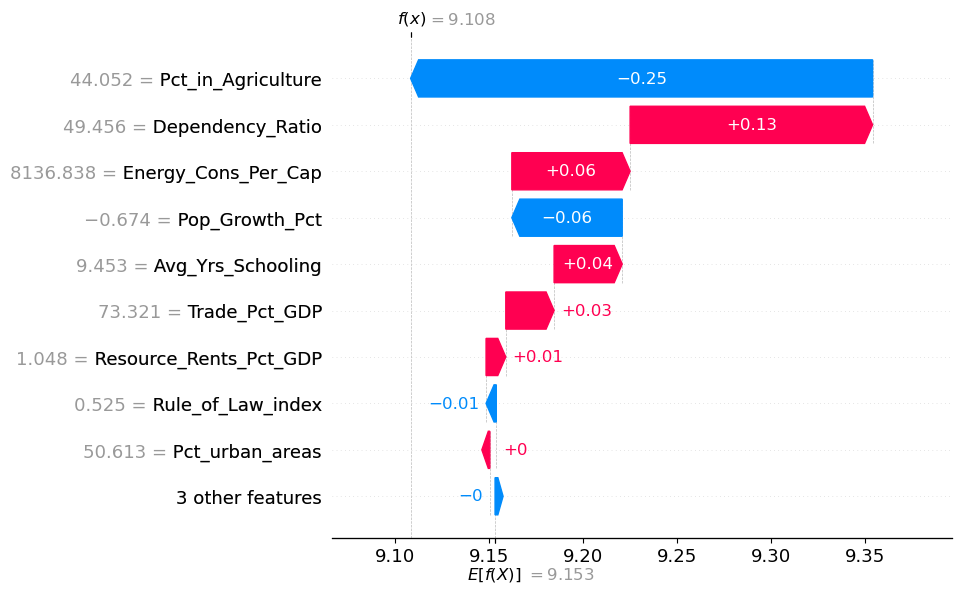

Country    Albania
Year          2009
Name: 9, dtype: object

In [78]:
shap.plots.waterfall(shap_values[9])

Development_df_filtered.loc[X_SHAP.index[9], ['Country', 'Year']]

In [79]:
X_SHAP.describe()

#As an example, fixed capital formation has a mean of 23.092. For value number 10 (shap_value[9]), this means that the effect of fixed capital
#formation being ~10% higher than the average contributed to ln(GDP) being 0.03 units lower

,Avg_Yrs_Schooling,Dependency_Ratio,Energy_Cons_Per_Cap,EPop_Pct,Fixed_Capital_Format_GDPpct,Global_Commodity_Price_Index,Pct_in_Agriculture,Pct_urban_areas,Pop_Growth_Pct,Resource_Rents_Pct_GDP,Rule_of_Law_index,Trade_Pct_GDP
count,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000
mean,8.288144,61.348165,22756.277718,56.429434,23.924139,7.443647,27.414565,58.141116,1.266093,6.711727,0.567016,77.932375
std,3.364483,17.738421,29306.901029,11.312050,7.204906,19.660239,22.193935,20.811525,1.194740,10.360643,0.304060,35.638262
min,0.980000,17.303247,103.924520,20.323000,1.096810,-31.805320,0.570907,11.641476,-1.990632,0.000000,0.015000,4.127549
25%,5.692789,48.375215,3112.499100,49.435500,19.349456,-7.015290,7.170122,41.362703,0.399977,0.655177,0.293000,50.824012
50%,8.459223,54.860781,11860.711000,56.708500,23.195420,12.706460,21.718705,60.151960,1.246227,2.309094,0.574000,70.288942
75%,11.190000,74.252597,32098.680500,62.849500,27.509148,23.335480,42.722597,73.939085,2.157049,7.945257,0.866000,97.820664
max,14.296371,111.208850,255475.860000,87.407000,49.166823,52.556390,89.161540,100.000000,3.999120,79.430950,0.998000,199.742580


                     Feature  Mean_ABS_SHAP
         Energy_Cons_Per_Cap       0.658549
          Pct_in_Agriculture       0.197348
             Pct_urban_areas       0.077505
Global_Commodity_Price_Index       0.075456
            Dependency_Ratio       0.062583
           Rule_of_Law_index       0.056797
                    EPop_Pct       0.045303
           Avg_Yrs_Schooling       0.044714
      Resource_Rents_Pct_GDP       0.041813
              Pop_Growth_Pct       0.022688
               Trade_Pct_GDP       0.022614
 Fixed_Capital_Format_GDPpct       0.013057


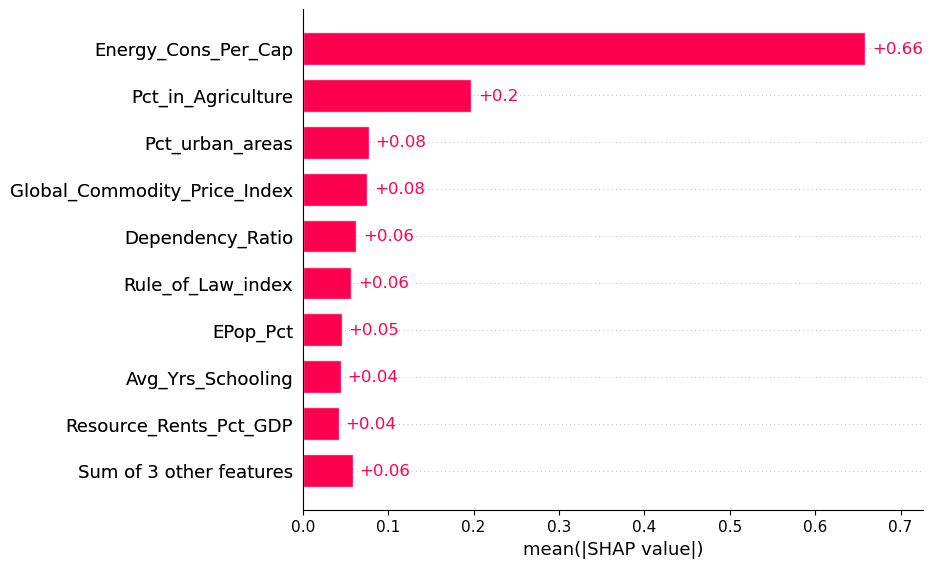

In [396]:
shap_importance = pd.DataFrame({
    "Feature": X_SHAP.columns,
    "Mean_ABS_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_ABS_SHAP", ascending=False)

print(shap_importance.to_string(index=False))

shap.plots.bar(shap_values)

#This is essentially the average effect that each of these variables have on the log of GDP (effectively average absolute value).
#Predictably, per capita energy consumption has the largest impact on GDP Per Capita, as the feature importance said

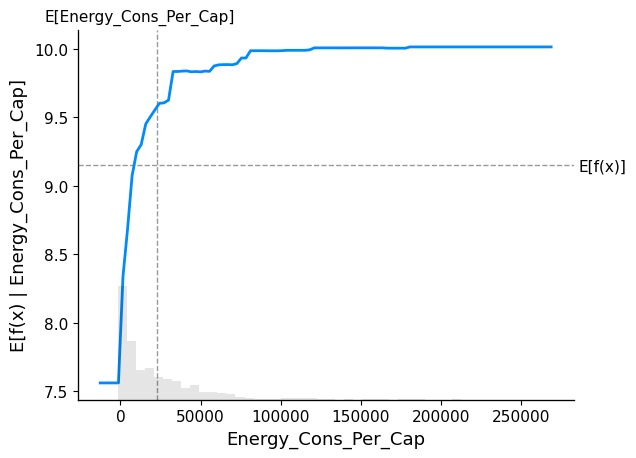

In [82]:
shap.partial_dependence_plot(
    "Energy_Cons_Per_Cap",
    best_model_SHAP.predict,
    X_SHAP,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

#This shows the partial dependence plot for energy consumption, showing how much the log of per capita GDP was on average at each value of
#energy consumption. For instance, at 50,000 kWh per capita, that value was roughly 9.8 ($18,034) when all other variables were held constant.
#This one follows a log shape because energy consumption is best shown as a log

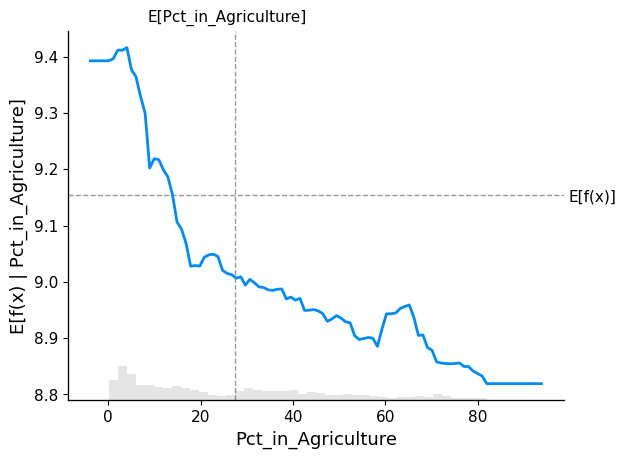

In [84]:
shap.partial_dependence_plot(
    "Pct_in_Agriculture",
    best_model_SHAP.predict,
    X_SHAP,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

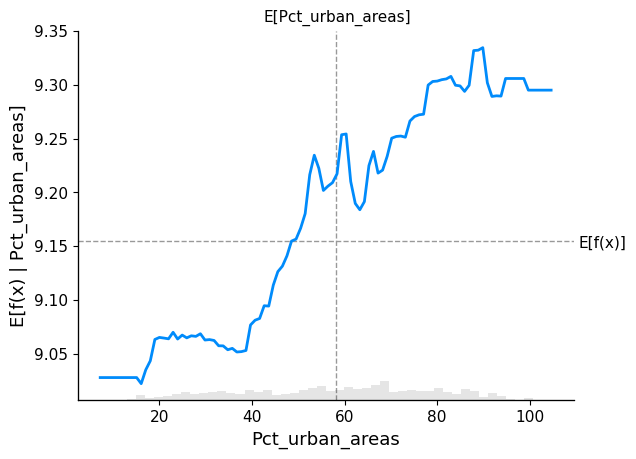

In [85]:
shap.partial_dependence_plot(
    "Pct_urban_areas",
    best_model_SHAP.predict,
    X_SHAP,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [189]:
y2 = Development_df_filtered['HDI']
X2 = Development_df_filtered[['Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct', 'Fixed_Capital_Format_GDPpct',
                              'Global_Commodity_Price_Index', 'Pct_in_Agriculture', 'Pct_urban_areas',
                              'Pop_Growth_Pct', 'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP']]


#For X2, I took all of the nonlinear transformations that existed in the original regression model,
#and replaced them with their linear variables
#This included keeping Energy_Cons_Per_Cap, Priv_Credit_Pct_GDP, 'Resource_Rents_Pct_GDP', and 'Global_Commodity_Price_Index'


print(X2.columns)



X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=17)


xgb_model2 = xgb.XGBRegressor(
    random_state=17
)

param_grid_SHAP2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.4, 0.5, 0.6],
    'colsample_bytree': [0.8, 0.9, 1.0]
}



grid_search_SHAP2 = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP2, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP2.fit(X2_train, y2_train)

Index(['Dependency_Ratio', 'Energy_Cons_Per_Cap', 'EPop_Pct',
       'Fixed_Capital_Format_GDPpct', 'Global_Commodity_Price_Index',
       'Pct_in_Agriculture', 'Pct_urban_areas', 'Pop_Growth_Pct',
       'Resource_Rents_Pct_GDP', 'Rule_of_Law_index', 'Trade_Pct_GDP'],
      dtype='object')


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.4, 0.5, 0.6]},
             scoring='neg_root_mean_squared_error')

In [180]:
print(grid_search_SHAP2.best_params_)
print(grid_search_SHAP2.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.6}
-0.01957319861379894


In [181]:
param_grid_SHAP2_new = {
    'n_estimators': [300, 400, 500, 600, 700, 800, 900, 1000],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.075, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [1.0]
}



grid_search_SHAP2_new = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP2_new, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP2_new.fit(X2_train, y2_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0],
                         'learning_rate': [0.075, 0.1, 0.2],
                         'max_depth': [5, 6, 7],
                         'n_estimators': [300, 400, 500, 600, 700, 800, 900,
                                          1000],
                         'subsample': [0.6, 0.7, 0.8]},
             scoring='neg_root_mean_squared_error')

Exception ignored in: <function ResourceTracker.__del__ at 0x10672dc60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107169c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102f05c60>
Traceback (most rece

In [182]:
print(grid_search_SHAP2_new.best_params_)
print(grid_search_SHAP2_new.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.075, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.8}
-0.0187814318552043


In [183]:
param_grid_SHAP2_3 = {
    'n_estimators': [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000],
    'max_depth': [5],
    'learning_rate': [0.075],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [1.0]
}



grid_search_SHAP2_3 = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP2_3, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP2_3.fit(X2_train, y2_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'learning_rate': [0.075],
                         'max_depth': [5],
                         'n_estimators': [1000, 1500, 2000, 2500, 3000, 3500,
                                          4000, 4500, 5000],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='neg_root_mean_squared_error')

In [184]:
print(grid_search_SHAP2_3.best_params_)
print(grid_search_SHAP2_3.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.075, 'max_depth': 5, 'n_estimators': 5000, 'subsample': 0.8}
-0.018765776224473583


In [185]:
param_grid_SHAP2_last = {
    'n_estimators': [5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 46000, 47000, 48000, 49000, 50000, 51000, 52000, 53000, 54000, 55000, 56000, 57000, 58000, 59000, 60000, 61000, 62000, 63000, 64000, 65000, 66000],
    'max_depth': [5],
    'learning_rate': [0.075],
    'subsample': [0.8],
    'colsample_bytree': [1.0]
}



grid_search_SHAP2_last = GridSearchCV(estimator=xgb_model, param_grid=param_grid_SHAP2_last, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1)

grid_search_SHAP2_last.fit(X2_train, y2_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'learning_rate': [0.075],
                         'max_depth': [5],
                         'n_estimators': [5000, 6000, 7000, 8000, 9000, 10000,
                                          11000, 12000, 13000, 14000, 15000,
                                          16000, 17000, 18000, 19000, 20000,
                                          21000, 22000, 23000, 24000, 25000,
                                          26000, 27000, 28000, 29000, 30000,
                                          31000, 32000, 33000, 34000, ...],
                         'subsample': [0.8]},
             scoring='neg_root_mean_squared_error')

Exception ignored in: <function ResourceTracker.__del__ at 0x11016dc60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102cc1c60>
Traceback (most recent call last):
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102781c60>
Traceback (most rece

In [186]:
print(grid_search_SHAP2_last.best_params_)
print(grid_search_SHAP2_last.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.075, 'max_depth': 5, 'n_estimators': 65000, 'subsample': 0.8}
-0.018756754781372034


In [187]:
best_model_SHAP2 = grid_search_SHAP2_last.best_estimator_
print(best_model_SHAP2)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.075, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=65000,
             n_jobs=None, num_parallel_tree=None, ...)


In [397]:
explainer2 = shap.Explainer(best_model_SHAP2)

X2_SHAP = X2[X2_train_group.columns]

print(X2_SHAP.columns.equals(X2_train_group.columns))

shap_values2 = explainer2(X2_SHAP)

#Once again, I could've done X2_test, but I chose X2 because I already made the model, and I wanted this to give the SHAP values for all of
#The country year observations
#Similarly to shap_values, I used X2_SHAP instead of X2 to fix the ordering

True


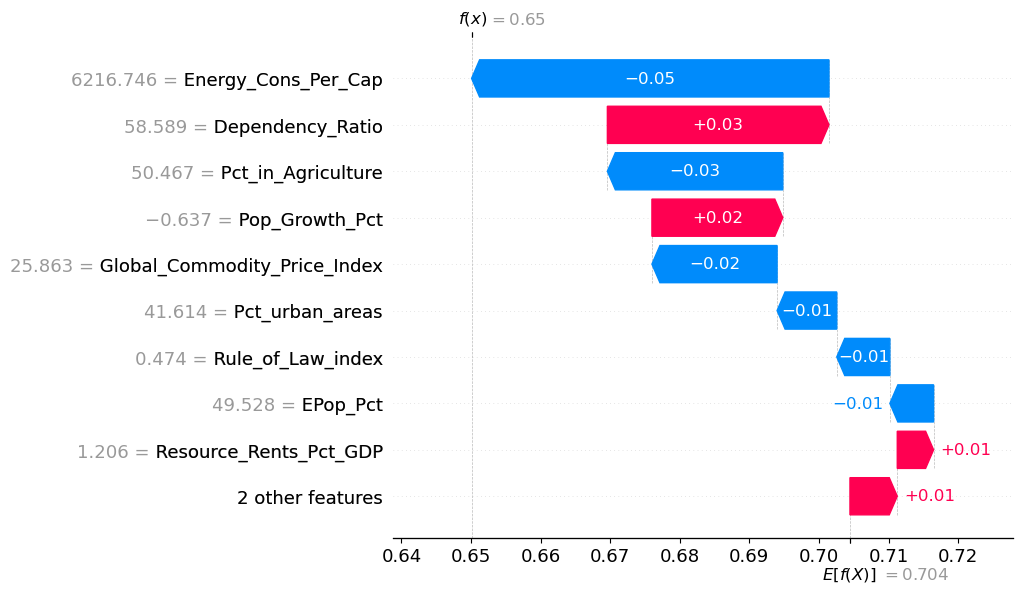

Country    Albania
Year          2000
Name: 0, dtype: object

In [399]:
shap.plots.waterfall(shap_values2[0])
Development_df_filtered.loc[X2_SHAP.index[0], ['Country', 'Year']]


#This is a waterfall plot for how the variables from the model affect the HDI of a country year observation
#In this case, that's Albania in 2000.
#Predictably, energy consumption is the primary driver of the discrepancy between the baseline value
#(0.704 for all observations), and the actual value of 0.650

#As was the case with the GDP one, this isn't the exact same as the actual HDI that year, but it's the modeled one that SHAP produces.
#The actual value was 0.682


#Here, this gives us the effect that each of these have on HDI. It'll go one of a few ways, the value for the variable
#is above the sample average and that has a positive effect on HDI, or vice versa (indicating a variable with a negative effect on HDI)
#or the value is below the sample average and that has a negative effect on HDI, or vice versa (indicating that the variable in question
#has a negative effect on HDI)

#Here energy consumption is below average, and that has a negative effect on HDI, meaning that higher energy consumption leads to a higher HDI
#Dependency ratio is below the average and that has a positive effect on HDI, which means that they're negatively correlated.
#Here there are more people in agriculture than average, and that also has a negative effect, meaning that more people in agriculture
#is a drag on quality of life
#Population growth is below the average (and negative outright) which has a positive effect on HDI meaning that increased population growth
#contributes to a lower HDI
#In this year, the commodity price index change (the variable is expressed as a percent change relative to the prior year)
#is well above average, which has a negative effect, meaning that there's a negative correlation between it and HDI
#There are fewer people in urban areas than the sample average, which has a negative effect,
#meaning urbanization has a positive effect on HDI
#The Rule of Law index is below the sample average, which is having a negative effect on HDI, which means the two have a positive relationship
#EPop Ratio is also below the sample average, also having a negative effect on HDI, which means the two have a positive relationship
#Resource rents are below the sample average here which has a positive effect on HDI which means the two have a negative relationship.

#For Albania (the country used here), Energy Consumption's effect on GDP and HDI flips in the early 2000s, going from positively correlated 
#to negatively so, however, this is relatively unique to Albania, other country year observations tend to show a positive relationship.

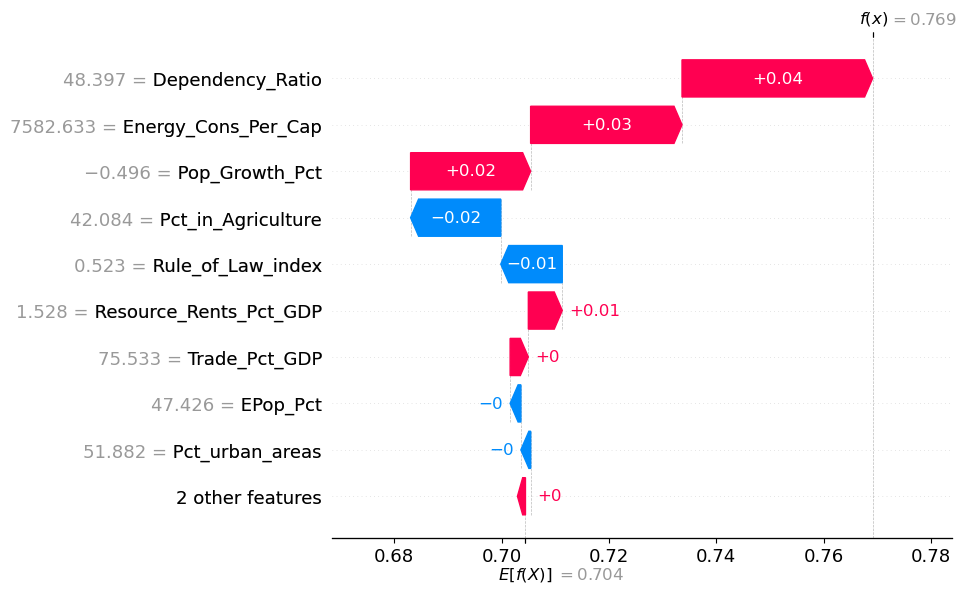

Country    Albania
Year          2010
Name: 10, dtype: object

In [104]:
shap.plots.waterfall(shap_values2[10])

Development_df_filtered.loc[X2_SHAP.index[10], ['Country', 'Year']]

In [105]:
X2_SHAP.describe()

#As an example, the Rule of Law Index has a mean of 0.564. For value number 10 (shap_value[9]), this means that the effect of Rule of Law
#being ~0.1 lower than the average contributed to HDI being 0.01 units lower

,Dependency_Ratio,Energy_Cons_Per_Cap,EPop_Pct,Fixed_Capital_Format_GDPpct,Global_Commodity_Price_Index,Pct_in_Agriculture,Pct_urban_areas,Pop_Growth_Pct,Resource_Rents_Pct_GDP,Rule_of_Law_index,Trade_Pct_GDP
count,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000
mean,61.348165,22756.277718,56.429434,23.924139,7.443647,27.414565,58.141116,1.266093,6.711727,0.567016,77.932375
std,17.738421,29306.901029,11.312050,7.204906,19.660239,22.193935,20.811525,1.194740,10.360643,0.304060,35.638262
min,17.303247,103.924520,20.323000,1.096810,-31.805320,0.570907,11.641476,-1.990632,0.000000,0.015000,4.127549
25%,48.375215,3112.499100,49.435500,19.349456,-7.015290,7.170122,41.362703,0.399977,0.655177,0.293000,50.824012
50%,54.860781,11860.711000,56.708500,23.195420,12.706460,21.718705,60.151960,1.246227,2.309094,0.574000,70.288942
75%,74.252597,32098.680500,62.849500,27.509148,23.335480,42.722597,73.939085,2.157049,7.945257,0.866000,97.820664
max,111.208850,255475.860000,87.407000,49.166823,52.556390,89.161540,100.000000,3.999120,79.430950,0.998000,199.742580


                     Feature  Mean_ABS_SHAP
         Energy_Cons_Per_Cap       0.090823
            Dependency_Ratio       0.028314
          Pct_in_Agriculture       0.024122
           Rule_of_Law_index       0.013720
             Pct_urban_areas       0.008343
Global_Commodity_Price_Index       0.007383
                    EPop_Pct       0.006942
              Pop_Growth_Pct       0.005815
      Resource_Rents_Pct_GDP       0.005594
               Trade_Pct_GDP       0.002495
 Fixed_Capital_Format_GDPpct       0.001589


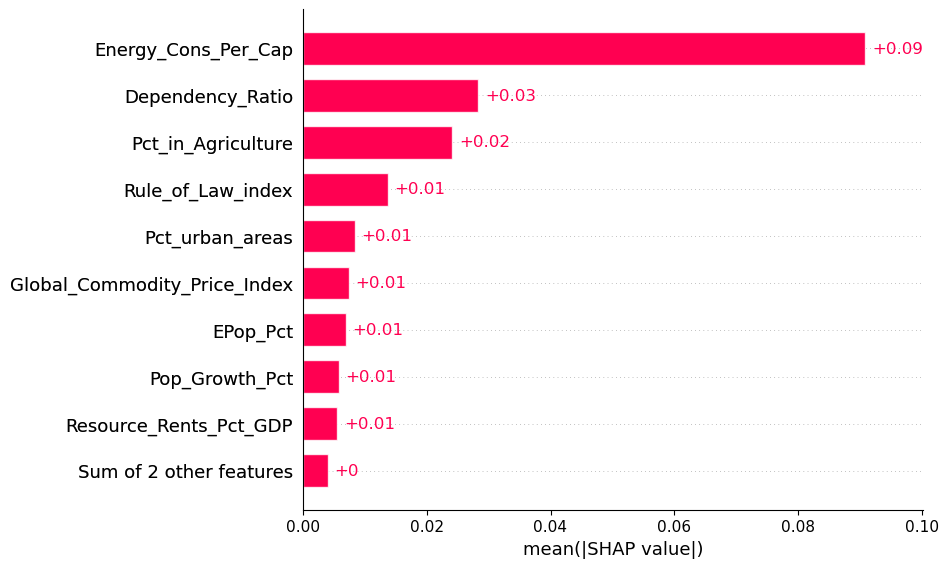

In [400]:
shap_importance2 = pd.DataFrame({
    "Feature": X2_SHAP.columns,
    "Mean_ABS_SHAP": np.abs(shap_values2.values).mean(axis=0)
}).sort_values("Mean_ABS_SHAP", ascending=False)

print(shap_importance2.to_string(index=False))

shap.plots.bar(shap_values2)

#This is essentially the average effect that each of these variables have on HDI (effectively average absolute value).
#Predictably, per capita energy consumption has the largest impact on HDI, as the feature importance model said

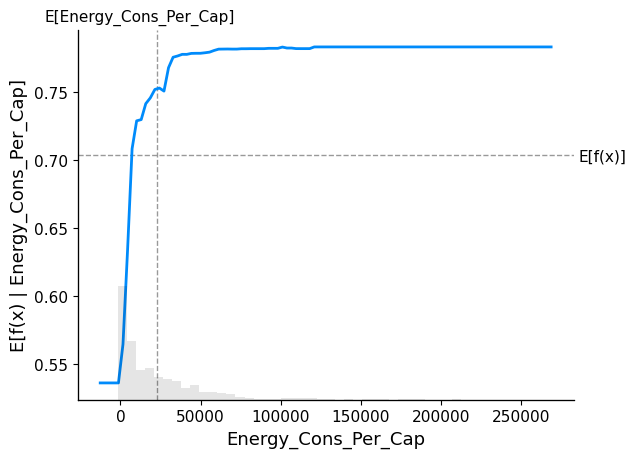

In [107]:
shap.partial_dependence_plot(
    "Energy_Cons_Per_Cap",
    best_model_SHAP2.predict,
    X2_SHAP,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

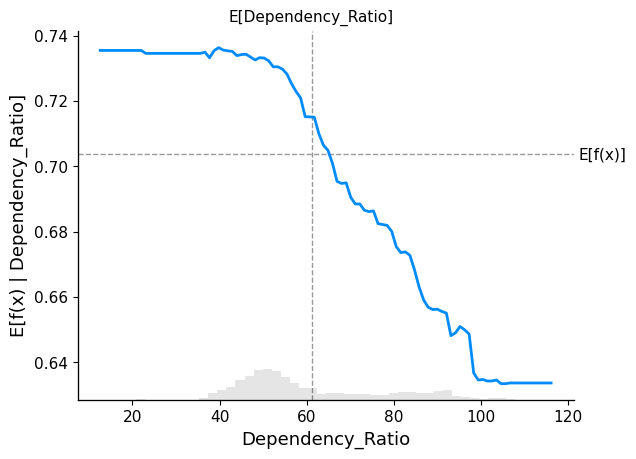

In [109]:
shap.partial_dependence_plot(
    "Dependency_Ratio",
    best_model_SHAP2.predict,
    X2_SHAP,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

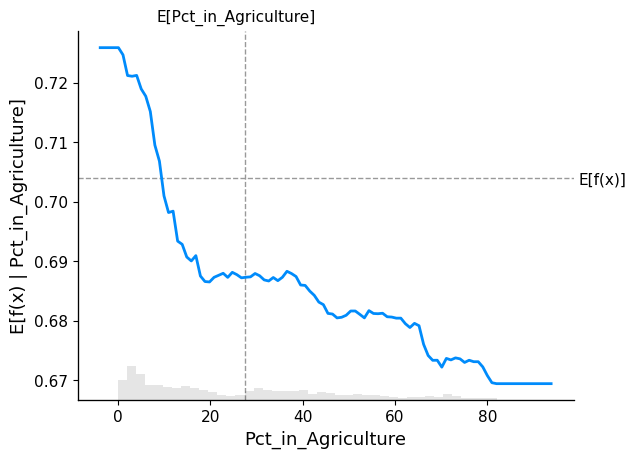

In [108]:
shap.partial_dependence_plot(
    "Pct_in_Agriculture",
    best_model_SHAP2.predict,
    X2_SHAP,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [383]:
y_test_pred

array([ 8.9258203 ,  7.99756855,  7.81643688, 10.13376585,  8.54177182,
        8.12891937, 10.68600015,  9.87246726,  9.53752887,  8.85338569,
       10.50954892, 10.21218998,  8.85808817,  8.46316098, 10.49081713,
        9.09101206, 10.37593143,  7.98794703,  7.24091054,  8.92523172,
        8.17001152, 10.00145181,  8.43948759,  7.91152095,  9.97958725,
       10.86768449,  9.34241407,  7.70664595,  9.16038623,  7.51465881,
        7.24136902,  8.59541468, 10.57573489,  8.13720611, 10.78373103,
       10.37405074,  9.51790162,  7.77505971,  9.73170746,  9.77833587,
       10.57900048,  9.70614115,  8.31084769,  7.92300643,  8.04999396,
        9.2183768 , 10.44871948,  7.66737452,  7.57910306, 10.19303991,
        9.69417609,  8.15547515,  9.49534924,  8.87585002,  7.91236294,
        8.86704623, 10.56776734,  8.19947182,  7.88722739,  9.22627699,
       10.79828009, 10.55174144,  8.5510781 ,  8.82619299,  8.02692051,
        9.3251213 ,  8.31727548,  8.99894335,  9.52081615,  7.50

In [384]:
y2_test_pred

array([0.68538916, 0.52081386, 0.51674333, 0.80629978, 0.55357466,
       0.47757253, 0.87779792, 0.77688089, 0.74550336, 0.698218  ,
       0.88583245, 0.86416207, 0.67877582, 0.69724668, 0.90909896,
       0.69616963, 0.8981048 , 0.5736288 , 0.47898791, 0.75918442,
       0.56366547, 0.84969306, 0.61358064, 0.56302196, 0.73701551,
       0.9441071 , 0.74206774, 0.42276115, 0.69926292, 0.48205375,
       0.42817212, 0.56833152, 0.91466939, 0.56763711, 0.94294982,
       0.88574316, 0.80984126, 0.45535003, 0.80381512, 0.80538488,
       0.90355066, 0.75650849, 0.61607787, 0.50443422, 0.58138721,
       0.80215354, 0.86571332, 0.50104744, 0.49684651, 0.81229836,
       0.80566019, 0.66254161, 0.76092328, 0.68403159, 0.48696506,
       0.61587971, 0.89511176, 0.54858724, 0.42273568, 0.78665398,
       0.91405541, 0.90779391, 0.70391639, 0.66678577, 0.5849965 ,
       0.72011537, 0.54285662, 0.60138764, 0.73376986, 0.54910648,
       0.48721826, 0.87861204, 0.93055395, 0.92024662, 0.91720

In [401]:
Determinants_of_GDP_and_HDI = Development_df_filtered.copy()

In [402]:
Determinants_of_GDP_and_HDI["Predicted_log_GDP_Per_Capita_gbr"] = np.nan
Determinants_of_GDP_and_HDI["Predicted_HDI_gbr"] = np.nan


Determinants_of_GDP_and_HDI.loc[X_all_group.index, "Predicted_log_GDP_Per_Capita_gbr"] = y_all_pred
Determinants_of_GDP_and_HDI.loc[X2_all_group.index, "Predicted_HDI_gbr"] = y2_all_pred

#Determinants_of_GDP_and_HDI.loc[X_test.index, "Predicted_log_GDP_Per_Capita"] = y_all_pred
#Determinants_of_GDP_and_HDI.loc[X2_test.index, "Predicted_HDI"] = y2_all_pred
#These were the original columns when making the new columns based on the test values, but I transformed them so that they'd comprise all X
#and X2 values
#This is from the area related to feature importance, 

In [403]:
shap_values.values

array([[ 0.08093313,  0.01466232, -0.39838064, ..., -0.01694217,
         0.00234236,  0.00569219],
       [ 0.07636905,  0.03124135, -0.37266186, ..., -0.00215895,
         0.01190103,  0.0258935 ],
       [ 0.06797037,  0.0289519 , -0.11316987, ..., -0.0100269 ,
        -0.00706572,  0.01099942],
       ...,
       [ 0.12522961, -0.08674021, -0.63004535, ..., -0.02586653,
        -0.10865736,  0.04485819],
       [ 0.12779935, -0.06278976, -0.6358784 , ..., -0.0256024 ,
        -0.11285271,  0.06828706],
       [ 0.13160567, -0.06446462, -0.62829036, ..., -0.01686576,
        -0.11860227,  0.0614932 ]], dtype=float32)

In [404]:
shap_values2.values

array([[ 3.18429358e-02, -5.13511971e-02, -6.28193468e-03, ...,
         5.21962205e-03, -7.63235707e-03,  3.11215874e-03],
       [ 2.93073542e-02, -2.37639081e-02, -5.69471950e-03, ...,
         8.46217666e-03, -5.92399621e-03,  3.04286648e-03],
       [ 1.98208522e-02,  1.53409587e-02, -4.60887421e-03, ...,
         7.87963346e-03, -1.00084851e-02,  2.47270265e-03],
       ...,
       [-3.44073884e-02, -8.92256349e-02,  8.20858032e-03, ...,
        -9.37406439e-04, -8.00599158e-03,  2.85049807e-03],
       [-1.41423242e-02, -1.08103864e-01,  8.29097535e-03, ...,
         3.89012530e-05, -8.04633833e-03, -1.53339736e-03],
       [-1.69635061e-02, -1.05307639e-01,  8.42598174e-03, ...,
        -8.18434462e-04, -7.50352535e-03,  4.03748685e-03]], dtype=float32)

In [389]:
shap_values.base_values
shap_values2.base_values

array([0.704455, 0.704455, 0.704455, ..., 0.704455, 0.704455, 0.704455],
      dtype=float32)

In [434]:
Determinants_of_GDP_and_HDI["GDP_Base_Value"] = shap_values.base_values

for i, feature in enumerate(X.columns):
    Determinants_of_GDP_and_HDI[f"GDP_SHAP_{feature}"] = shap_values.values[:, i]

In [435]:
Determinants_of_GDP_and_HDI["HDI_Base_Value"] = shap_values2.base_values

for i, feature in enumerate(X2.columns):
    Determinants_of_GDP_and_HDI[f"HDI_SHAP_{feature}"] = shap_values2.values[:, i]

In [436]:
Determinants_of_GDP_and_HDI["Predicted_log_GDP_SHAP"] = (
    shap_values.base_values + shap_values.values.sum(axis=1)
)

In [437]:
Determinants_of_GDP_and_HDI["Predicted_HDI_SHAP"] = (
    shap_values2.base_values + shap_values2.values.sum(axis=1)
)

In [438]:
Determinants_of_GDP_and_HDI.head(10)

,index,Country,Year,Avg_Yrs_Schooling,Dependency_Ratio,Energy_Cons_Per_Cap,EPop_Pct,Fixed_Capital_Format_GDPpct,GDP_Per_Capita_PPP,Global_Commodity_Price_Index,HDI,Pct_in_Agriculture,Pct_urban_areas,Pop_Growth_Pct,Resource_Rents_Pct_GDP,Rule_of_Law_index,Trade_Pct_GDP,PopGrowth_squared,PopGrowth_cubed,CapFormation_squared,log_GDP_PPP,log_Agri,log_Energy,log_Rents,EPop_squared,EPop_cubed,Rents_Energy,PopGrowth_Dependency,Rents_Commodity_Price_Index,PopGrowth_FixedCapital,Predicted_log_GDP_Per_Capita_gbr,Predicted_HDI_gbr,GDP_Base_Value,GDP_SHAP_Avg_Yrs_Schooling,GDP_SHAP_Dependency_Ratio,GDP_SHAP_Energy_Cons_Per_Cap,GDP_SHAP_EPop_Pct,GDP_SHAP_Fixed_Capital_Format_GDPpct,GDP_SHAP_Global_Commodity_Price_Index,GDP_SHAP_Pct_in_Agriculture,GDP_SHAP_Pct_urban_areas,GDP_SHAP_Pop_Growth_Pct,GDP_SHAP_Resource_Rents_Pct_GDP,GDP_SHAP_Rule_of_Law_index,GDP_SHAP_Trade_Pct_GDP,HDI_Base_Value,HDI_SHAP_Dependency_Ratio,HDI_SHAP_Energy_Cons_Per_Cap,HDI_SHAP_EPop_Pct,HDI_SHAP_Fixed_Capital_Format_GDPpct,HDI_SHAP_Global_Commodity_Price_Index,HDI_SHAP_Pct_in_Agriculture,HDI_SHAP_Pct_urban_areas,HDI_SHAP_Pop_Growth_Pct,HDI_SHAP_Resource_Rents_Pct_GDP,HDI_SHAP_Rule_of_Law_index,HDI_SHAP_Trade_Pct_GDP,Predicted_log_GDP_SHAP,Predicted_HDI_SHAP
0,0,Albania,2000,8.750522,58.588726,6216.7456,49.528,34.040139,3977.793158,25.86253,0.682,50.467464,41.613583,-0.637357,1.205807,0.474,61.609260,0.406224,-0.258909,1158.731078,8.288734,3.940950,8.735163,0.791093,2453.022784,121493.312446,7496.192875,-37.341925,31.185209,-21.695715,8.217524,0.633227,9.153137,0.080933,0.014662,-0.398381,-0.004512,-0.030515,-0.234099,-0.264665,-0.077160,-0.037781,-0.016942,0.002342,0.005692,0.704455,0.031843,-0.051351,-0.006282,0.003685,-0.017985,-0.025206,-0.008573,0.018804,0.005220,-0.007632,0.003112,8.192713,0.650090
1,1,Albania,2001,8.820000,57.827007,6383.7065,48.965,38.228045,4450.511351,-7.01529,0.691,49.435272,42.354515,-0.938470,0.774294,0.518,64.247444,0.880727,-0.826536,1461.383449,8.400999,3.920691,8.761661,0.573403,2397.571225,117397.075032,4942.868833,-54.268936,-5.431900,-35.875890,8.321287,0.642308,9.153137,0.076369,0.031241,-0.372662,-0.008460,-0.006306,-0.165290,-0.253588,-0.063330,-0.026205,-0.002159,0.011901,0.025893,0.704455,0.029307,-0.023764,-0.005695,0.001970,-0.011815,-0.024166,-0.008028,0.023460,0.008462,-0.005924,0.003043,8.400542,0.691305
2,2,Albania,2002,8.885714,56.728830,7213.5920,48.945,38.575336,4840.358546,-0.77551,0.697,48.371387,43.152042,-0.299877,0.765809,0.515,65.991460,0.089926,-0.026967,1488.056534,8.484951,3.899371,8.883861,0.568609,2395.613025,117253.279509,5524.232955,-17.011654,-0.593892,-11.567844,8.541172,0.667393,9.153137,0.067970,0.028952,-0.113170,-0.015524,-0.020519,-0.152835,-0.340192,-0.091950,-0.024572,-0.010027,-0.007066,0.010999,0.704455,0.019821,0.015341,-0.004609,0.000668,-0.011763,-0.030597,-0.010740,0.013334,0.007880,-0.010008,0.002473,8.485206,0.696253
3,3,Albania,2003,8.951428,55.605934,7441.4790,48.611,36.722128,5169.163145,17.50807,0.705,48.276344,44.029510,-0.374149,0.765832,0.511,64.823210,0.139988,-0.052376,1348.514716,8.550660,3.897444,8.914959,0.568622,2363.029321,114869.218323,5698.919769,-20.804914,13.408233,-13.739554,8.589904,0.685137,9.153137,0.057541,0.043990,-0.104394,-0.013762,-0.029752,-0.131745,-0.333605,-0.078726,-0.003980,-0.013761,-0.009333,0.015402,0.704455,0.021233,0.026397,-0.005321,-0.000246,-0.011263,-0.031050,-0.011007,0.014996,0.007457,-0.011751,0.001168,8.551011,0.705067
4,4,Albania,2004,9.017142,54.512900,8072.5440,48.121,36.331947,5594.816886,20.59162,0.710,47.916664,44.978493,-0.417931,0.868822,0.529,65.037940,0.174667,-0.072999,1320.010390,8.629775,3.890118,8.996348,0.625308,2315.630641,111430.462076,7013.600271,-22.782651,17.890443,-15.184261,8.693876,0.692921,9.153137,0.036964,0.073944,-0.047122,-0.000577,-0.032268,-0.118704,-0.355035,-0.068628,-0.013733,-0.009816,-0.005714,0.016915,0.704455,0.024003,0.031699,-0.003562,-0.000755,-0.012040,-0.030981,-0.012209,0.014777,0.007038,-0.013023,0

In [439]:
GDP_feature_importance_and_SHAP = pd.DataFrame({
    "Feature_GDP": X_all_group.columns,
    "GBR_Feature_Importance_GDP": gbr_group_all_data.feature_importances_,
    "Mean_ABS_SHAP_GDP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_ABS_SHAP_GDP", ascending = False)


In [440]:
HDI_feature_importance_and_SHAP = pd.DataFrame({
    "Feature_HDI": X2_all_group.columns,
    "GBR_Feature_Importance_HDI": gbr2_group_all_data.feature_importances_,
    "Mean_ABS_SHAP_HDI": np.abs(shap_values2.values).mean(axis=0)
}).sort_values("Mean_ABS_SHAP_HDI", ascending = False)


In [441]:
Feature_Importance_and_SHAP_GDP_and_HDI = GDP_feature_importance_and_SHAP.merge(
    HDI_feature_importance_and_SHAP, left_on = "Feature_GDP", right_on = "Feature_HDI", how = "outer")

In [442]:
Feature_Importance_and_SHAP_GDP_and_HDI.head(15)

,Feature_GDP,GBR_Feature_Importance_GDP,Mean_ABS_SHAP_GDP,Feature_HDI,GBR_Feature_Importance_HDI,Mean_ABS_SHAP_HDI
0,Avg_Yrs_Schooling,0.015425,0.044714,NaN,NaN,NaN
1,Dependency_Ratio,0.017360,0.062583,Dependency_Ratio,0.056514,0.028314
2,EPop_Pct,0.023748,0.045303,EPop_Pct,0.008081,0.006942
3,Energy_Cons_Per_Cap,0.699802,0.658549,Energy_Cons_Per_Cap,0.716304,0.090823
4,Fixed_Capital_Format_GDPpct,0.006733,0.013057,Fixed_Capital_Format_GDPpct,0.004088,0.001589
5,Global_Commodity_Price_Index,0.012855,0.075456,Global_Commodity_Price_Index,0.001958,0.007383
6,Pct_in_Agriculture,0.154929,0.197348,Pct_in_Agriculture,0.140222,0.024122
7,Pct_urban_areas,0.026930,0.077505,Pct_urban_areas,0.016174,0.008343
8,Pop_Growth_Pct,0.009813,0.022688,Pop_Growth_Pct,0.013040,0.005815
9,Resource_Rents_Pct_GDP,0.013708,0.041813,Resource_Rents_Pct_GDP,0.009363,0.005594


In [415]:
Feature_Importance_and_SHAP_GDP_and_HDI.to_excel("/Users/keyan/Downloads/Final_Cleaned_Feature_Importance_and_SHAP_For_GDP_and_HDI.xlsx", index = False)

In [443]:
Determinants_of_GDP_and_HDI.to_excel("/Users/keyan/Downloads/Final_Cleaned_Determinants_of_Development_For_GDP_and_HDI.xlsx", index = False)